<a href="https://colab.research.google.com/github/lojainosama/lojainosama/blob/main/Copy_of_16_4secound_da499_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# `***CV HANDLING***`:




In [2]:


import pandas as pd
from zipfile import ZipFile

# `التعامل مع PDFور`

In [3]:
## تثبيت المكتبات والأدوات المطلوبة للمشروع.
# السطر الأول يثبت مكتبات Python التي سنستخدمها لتحميل الداتا، قراءة ملفات PDF،
# تحويلها إلى نص باستخدام OCR، ومعالجة البيانات باستخدام pandas.
# السطر الثاني يثبت برامج النظام (Tesseract و Poppler) اللازمة لاستخراج النص من الصور وملفات PDF.

!pip -q install kagglehub pymupdf pdf2image pytesseract pandas
!apt-get -qq install tesseract-ocr poppler-utils

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.0/25.0 MB 65.1 MB/s eta 0:00:00
Selecting previously unselected package poppler-utils.
(Reading database ... 118194 files and directories currently installed.)
Preparing to unpack .../poppler-utils_22.02.0-2ubuntu0.12_amd64.deb ...
Unpacking poppler-utils (22.02.0-2ubuntu0.12) ...
Setting up poppler-utils (22.02.0-2ubuntu0.12) ...
Processing triggers for man-db (2.10.2-1) ...


In [4]:
#os → للتعامل مع الملفات والمجلدات في النظام
#re → لاستخدام الـ Regular Expressions لتنظيف النص
#fitz (PyMuPDF) → لقراءة النص من ملفات PDF
#pytesseract → لاستخراج النص من الصور باستخدام OCR
#pandas → لتنظيم البيانات في جداول (DataFrame)
#kagglehub → لتحميل الداتا من Kaggle
#convert_from_path → لتحويل صفحات PDF إلى صور عند الحاجة لاستخدام OCR

import os
import re
import fitz
import pytesseract
import pandas as pd
import kagglehub
from pdf2image import convert_from_path

In [5]:
# تحميل مجموعة البيانات الخاصة بالسير الذاتية من Kaggle باستخدام مكتبة kagglehub.
# يتم حفظ مسار البيانات في المتغير path، ثم نطبع المسار للتأكد من مكان حفظ الداتا.
# كما نتحقق من أن المسار موجود فعلاً في البيئة باستخدام os.path.exists.

path = kagglehub.dataset_download("snehaanbhawal/resume-dataset")
print("Dataset path:", path)
print("Exists:", os.path.exists(path))

100%|██████████| 62.5M/62.5M [00:00<00:00, 113MB/s]

Extracting files...


Dataset path: /root/.cache/kagglehub/datasets/snehaanbhawal/resume-dataset/versions/1
Exists: True


In [ ]:

#os.walk(path) → يتنقل داخل جميع مجلدات الداتا.endswith(".pdf") → للتأكد أن الملف هو سيرة ذاتية بصيغة PDF.
#append → لإضافة مسار الملف إلى القائمة.
#len(all_pdfs) → لمعرفة عدد السير الذاتية الموجودة في الداتا.
#all_pdfs[:5] → لعرض أول 5 ملفات للتأكد من أن القراءة تمت بشكل صحيح.

all_pdfs = []
for root, dirs, files in os.walk(path):
    for f in files:
        if f.lower().endswith(".pdf"):
            all_pdfs.append(os.path.join(root, f))
print("Total CV files:", len(all_pdfs))
print(all_pdfs[:5])

In [ ]:
# الهدف من هذا الكود هو استخراج النص من ملفات السيرة الذاتية بصيغة PDF.
# نحاول أولاً استخراج النص مباشرة من ملف PDF باستخدام مكتبة fitz.
# إذا لم يتم استخراج النص بشكل جيد، نستخدم تقنية OCR لاستخراج النص من صور صفحات الـ PDF.

def extract_resume_text(pdf_path):

    text = ""

    try:
        doc = fitz.open(pdf_path)

        for page in doc:
            text += page.get_text() + "\n"

        doc.close()

    except Exception as e:
        print("Direct extraction failed:", pdf_path)

    if len(text.strip()) < 100:

        try:
            images = convert_from_path(pdf_path)

            ocr_text = ""

            for img in images:
                ocr_text += pytesseract.image_to_string(img) + "\n"

            text = ocr_text

        except Exception as e:
            print("OCR failed:", pdf_path)

    return text

In [8]:
#هون شلنا الشغلات الزايده بالنص تنظيف يعني
def clean_text(text):

    text = text.replace("ï¼​", " ")
    text = text.replace("\x0c", " ")

    text = re.sub(r"\s+", " ", text)

    return text.strip()

In [9]:
# الهدف من هذا الكود هو معالجة جميع ملفات السيرة الذاتية واستخراج النص منها.
# يتم المرور على كل ملف PDF، ثم استخراج النص باستخدام الدالة السابقة،
# وبعد ذلك تنظيف النص وتخزين المعلومات الأساسية (اسم الملف، الفئة، النص)
# داخل قائمة records ليتم تحويلها لاحقاً إلى Dataset.
records = []

for i, pdf_path in enumerate(all_pdfs):

    try:

        raw_text = extract_resume_text(pdf_path)

        cleaned_text = clean_text(raw_text)

        records.append({
            "file_name": os.path.basename(pdf_path),
            "category": os.path.basename(os.path.dirname(pdf_path)),
            "text": cleaned_text
        })

        if (i+1) % 100 == 0:
            print("Processed", i+1)

    except Exception as e:
        print("Error:", pdf_path)

Processed 100
Processed 200
Processed 300
Processed 400
Processed 500
Processed 600
Processed 700
Processed 800
Processed 900
Processed 1000
Processed 1100
Processed 1200
Processed 1300
Processed 1400
Processed 1500
Processed 1600
Processed 1700
Processed 1800
Processed 1900
Processed 2000
Processed 2100
Processed 2200
Processed 2300
Processed 2400


In [ ]:
# الهدف من هذا الكود هو تحويل البيانات التي تم جمعها في القائمة records
# إلى جدول بيانات (DataFrame) باستخدام مكتبة pandas.
# بعد ذلك نعرض عدد الصفوف والأعمدة في الداتا، ثم نعرض أول عدة سجلات
# للتأكد من أن البيانات تم استخراجها وتنظيمها بشكل صحيح.
df = pd.DataFrame(records)
df = df.rename(columns={
    "category": "job_title",
    "text": "resume"
})
df.drop('file_name', axis=1, inplace=True)
print("Dataset shape:", df.shape)

df.head()

In [ ]:
#هون بدنا نفلتر عشان ناخد ال it
it_categories = [
    "INFORMATION-TECHNOLOGY",
]

df_it = df[df["job_title"].isin(it_categories)]

In [ ]:
df_it.head()

In [13]:
print("All resumes:", df.shape)
print("IT resumes:", df_it.shape)

All resumes: (2484, 2)
IT resumes: (120, 2)


In [14]:
df_it.to_csv("/content/it_resumes_dataset.csv", index=False)

In [15]:
#تنزيل عالجهاز
from google.colab import files

files.download("/content/it_resumes_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

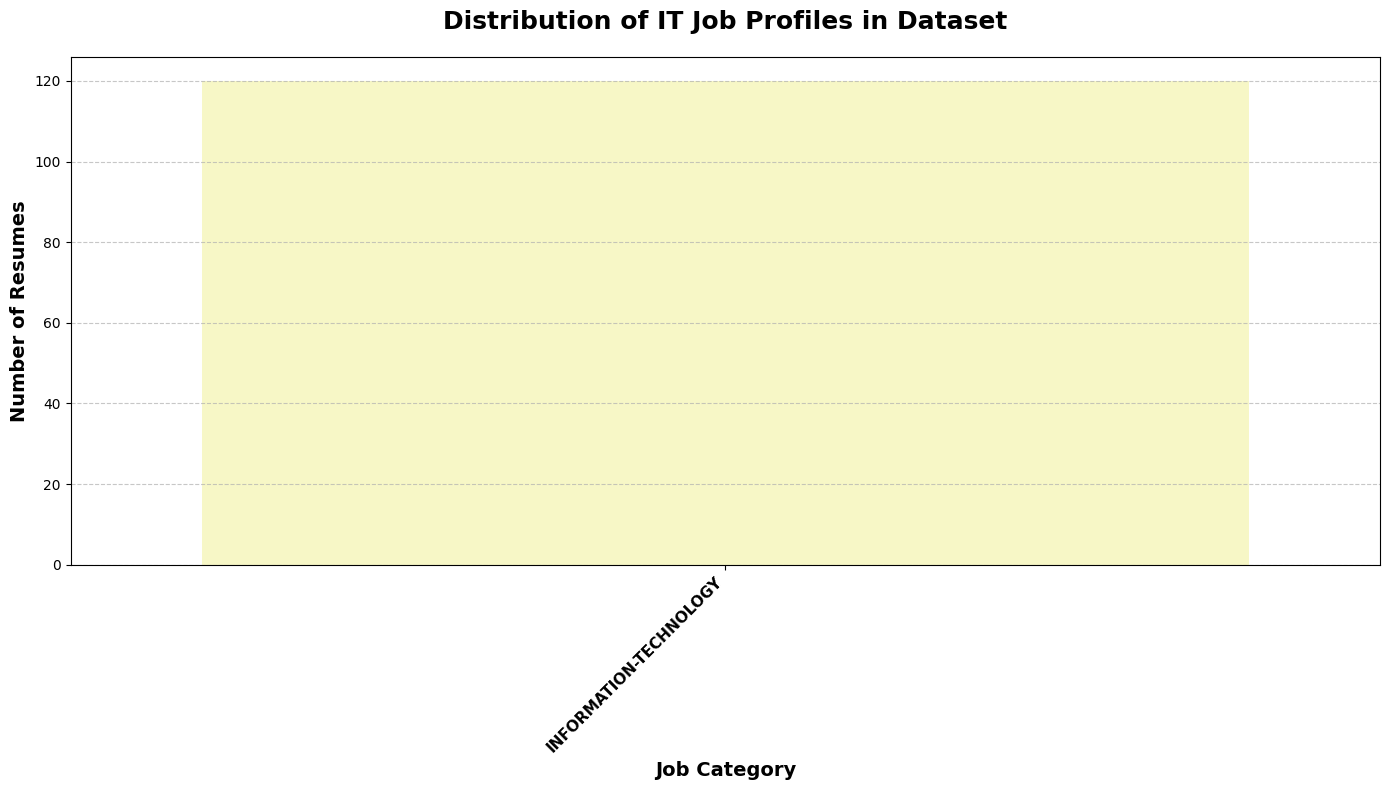

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 8))

ax = sns.countplot(data=df_it, x='job_title', hue='job_title', palette='Spectral', legend=False)

plt.xticks(rotation=45, ha='right', fontsize=11, fontweight='bold')

plt.title('Distribution of IT Job Profiles in Dataset', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Job Category', fontsize=14, fontweight='bold')
plt.ylabel('Number of Resumes', fontsize=14, fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()

plt.show()

# `التعامل مع الملفات الtext`

# ***`first file`***

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("muqaddasejaz/resume-cv-skills-extraction-dataset")

print("Path to dataset files:", path)
print(os.listdir(path))

100%|██████████| 383k/383k [00:00<00:00, 992kB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/muqaddasejaz/resume-cv-skills-extraction-dataset/versions/1
['UpdatedResumeDataSet.csv']


In [ ]:
import pandas as pd
import os

# Explicitly set the path for this dataset to avoid conflicts


df2 = pd.read_csv(os.path.join(path, 'UpdatedResumeDataSet.csv'))
df2.rename(columns={'Category':'job_title', 'Resume':'resume'}, inplace=True)

print(df2.shape)
df2.head()

(962, 2)


,job_title,resume
0,Data Science,Skills * Programming Languages: Python (pandas...
1,Data Science,Education Details \r\nMay 2013 to May 2017 B.E...
2,Data Science,"Areas of Interest Deep Learning, Control Syste..."
3,Data Science,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...
4,Data Science,"Education Details \r\n MCA YMCAUST, Faridab..."


In [ ]:
df2['job_title'].value_counts()

,count
job_title,
Java Developer,84
Testing,70
DevOps Engineer,55
Python Developer,48
Web Designing,45
HR,44
Hadoop,42
Sales,40
Data Science,40


In [ ]:
print("Dataset size:", df2.shape)

Dataset size: (962, 2)


# ***`fillter the IT-job tiltle`***

In [ ]:

it_jobs_list = [
    'Java Developer', 'Testing', 'DevOps Engineer', 'Python Developer',
    'Web Designing', 'Hadoop', 'Data Science', 'ETL Developer',
     'Database', 'DotNet Developer',
    'Automation Testing', 'Network Security Engineer', 'SAP Developer'
]

# 2. تصفية الـ DataFrame بحيث يحتوي فقط على هذه الوظائف
df2 = df2[df2['job_title'].isin(it_jobs_list)]

# 3. التأكد من النتيجة وحساب عدد كل وظيفة
print("IT Jobs Data Size:", df2.shape)
print("\nتوزيع الوظائف التقنية:")
print(df2['job_title'].value_counts())

# عرض عينة من البيانات المصفاة
display(df2.head())

IT Jobs Data Size: (560, 2)

توزيع الوظائف التقنية:
job_title
Java Developer               84
Testing                      70
DevOps Engineer              55
Python Developer             48
Web Designing                45
Hadoop                       42
ETL Developer                40
Data Science                 40
Database                     33
DotNet Developer             28
Automation Testing           26
Network Security Engineer    25
SAP Developer                24
Name: count, dtype: int64


,job_title,resume
0,Data Science,Skills * Programming Languages: Python (pandas...
1,Data Science,Education Details \r\nMay 2013 to May 2017 B.E...
2,Data Science,"Areas of Interest Deep Learning, Control Syste..."
3,Data Science,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...
4,Data Science,"Education Details \r\n MCA YMCAUST, Faridab..."


ائلة التطوير والبرمجة (Development) Java Developer: يركز على بناء الأنظمة الخلفية (Backend) للمؤسسات الكبيرة والبنوك وتطبيقات الأندرويد.
Python Developer: متخصص مرن يعمل غالباً في مجالات الذكاء الاصطناعي، الأتمتة، أو تطوير المواقع السريعة.

DotNet Developer: يستخدم تقنيات مايكروسوفت لبناء تطبيقات موجهة لبيئة الويندوز والأنظمة السحابية للمؤسسات.

SAP Developer: متخصص في تخصيص وبرمجة أنظمة "سيب" (SAP) التي تدير الموارد المالية والبشرية للشركات العملاقة.

Web Designing: يهتم بالجانب البصري والتفاعلي للمواقع (Frontend)، وكيفية جعل تجربة المستخدم سهلة وجذابة.

عائلة البيانات والذكاء الاصطناعي (Data Science & Analytics) Data Science: يجمع بين الإحصاء والبرمجة لاستخراج أنماط وتوقعات من البيانات لمساعدة الشركات في اتخاذ القرار.
Hadoop: متخصص في إدارة ومعالجة "البيانات الضخمة" (Big Data) التي تفشل قواعد البيانات التقليدية في التعامل معها.

Database: المهندس المسؤول عن تصميم وبناء وحماية مستودعات البيانات والتأكد من سرعتها.

ETL Developer: يختص بعمليات "نقل وتجهيز البيانات"؛ حيث يسحبها من مصادر مختلفة، ينظفها، ثم يضعها في مكانها النهائي للتحليل.

عائلة الجودة والأمن والعمليات (Infrastructure & QA) Testing: الشخص المسؤول عن فحص البرامج يدوياً للتأكد من خلوها من العيوب قبل إطلاقها.
Automation Testing: مبرمج يكتب أكواداً خاصة تقوم بمهمة "الفحص" تلقائياً لضمان الجودة بسرعة أكبر.

DevOps Engineer: هو الرابط بين فريق البرمجة وفريق التشغيل، ويهتم بتسريع وصول التحديثات إلى المستخدمين بشكل آلي.

Network Security Engineer: حارس الأمن الرقمي الذي يحمي الشبكات والبيانات من الاختراقات والهجمات السيبرانية.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

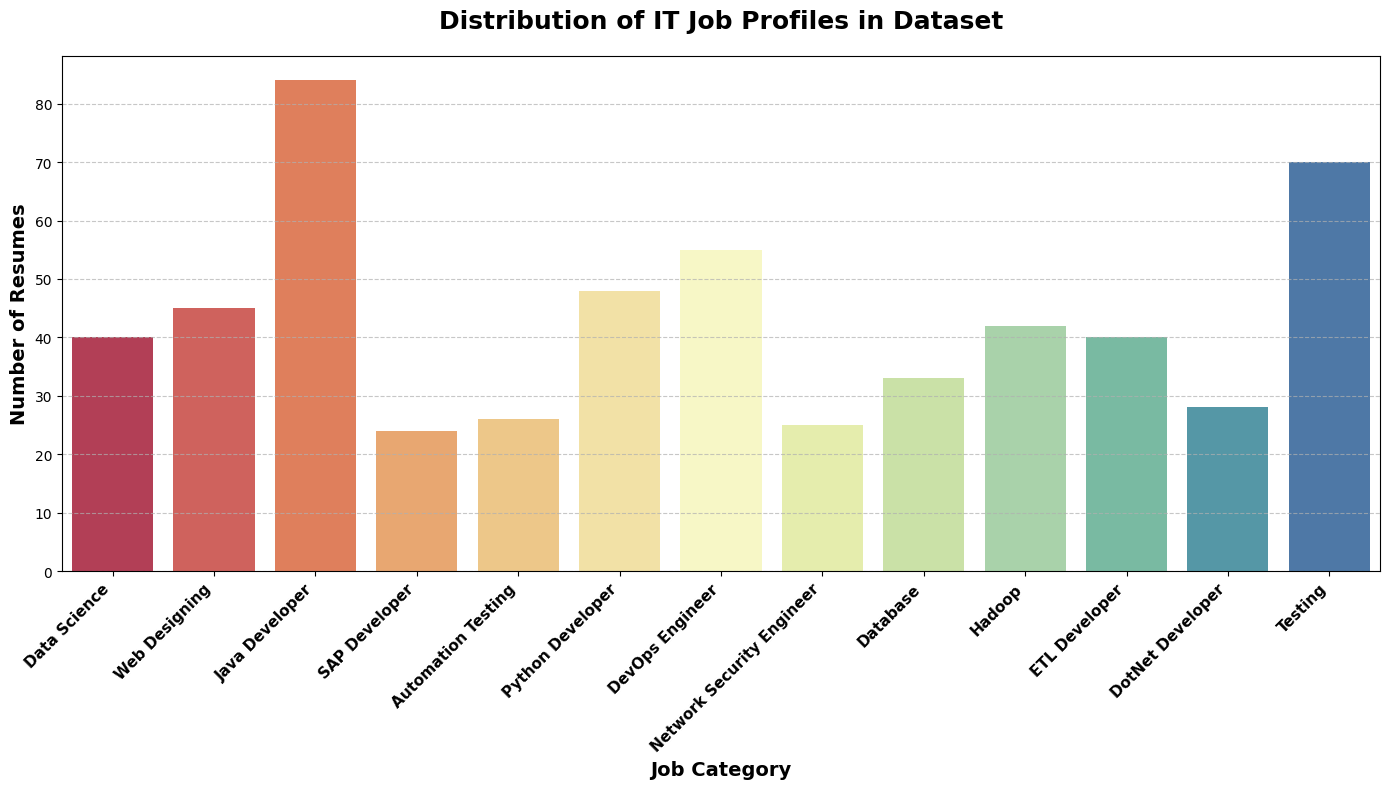

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 8))

ax = sns.countplot(data=df2, x='job_title', hue='job_title', palette='Spectral', legend=False)

plt.xticks(rotation=45, ha='right', fontsize=11, fontweight='bold')

plt.title('Distribution of IT Job Profiles in Dataset', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Job Category', fontsize=14, fontweight='bold')
plt.ylabel('Number of Resumes', fontsize=14, fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()

plt.show()

# ***`secound`***

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("haidermaseeh/resume-dataset")

print("Path to dataset files:", path)

print(os.listdir(path))

100%|██████████| 29.8M/29.8M [00:01<00:00, 17.6MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/haidermaseeh/resume-dataset/versions/1
['Resume dataset.csv']


In [ ]:
import pandas as pd
import os

df3= pd.read_csv(os.path.join(path, 'Resume dataset.csv'))

print(df3.shape)
df3.head()

(9000, 3)


,category,job_title,Text
0,Java Developers/Architects Resumes,Java Developer,Flair for technology and willing to take chall...
1,Java Developers/Architects Resumes,Sr. Java/J2EE Developer,Senior Java Developer with around 7+ years of ...
2,Java Developers/Architects Resumes,Sr. iOS Developer,Overall 7 years of experience in design and de...
3,Java Developers/Architects Resumes,Core Java Developer,7 + years of experience in Application Analysi...
4,Java Developers/Architects Resumes,Android Developer,With approx 5 years of experience in IT sector...


In [ ]:
df3['category'].value_counts()

,count
category,
Java Developers/Architects Resumes,1000
Web Developer Resumes,1000
SQL Developers Resumes,1000
Business Analyst (BA) Resumes,1000
Network and Systems Administrators Resumes,1000
"Datawarehousing, ETL, Informatica Resumes",1000
"Business Intelligence, Business Object Resumes",1000
Project Manager Resumes,1000
Recruiter Resumes,1000


# ***عملنا فلتر وتغير اسامي***

In [ ]:
# تغير اسامي ال الوظائف
it_mapping = {
    'Java Developers/Architects Resumes': 'java_dev',
    'Web Developer Resumes': 'web_dev',
    'SQL Developers Resumes': 'sql_dev',
    'Network and Systems Administrators Resumes': 'sys_admin',
    'Datawarehousing, ETL, Informatica Resumes': 'etl_data_eng',
    'Business Intelligence, Business Object Resumes': 'bi_dev'
}

# 2. تصفية الداتا سيت (إبقاء الـ IT فقط)
df3 = df3[df3['category'].isin(it_mapping.keys())].copy()

# 3. تغيير الأسماء للأسماء المختصرة
df3['category'] = df3['category'].map(it_mapping)
df3.drop('job_title', axis=1, inplace=True)
df3.rename(columns={'category': 'job_title','Text':'resume'}, inplace=True)

# التأكد من النتائج
print("Current IT Categories:")
print(df3['job_title'].value_counts())

Current IT Categories:
job_title
java_dev        1000
web_dev         1000
sql_dev         1000
sys_admin       1000
etl_data_eng    1000
bi_dev          1000
Name: count, dtype: int64


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

***data exploring***

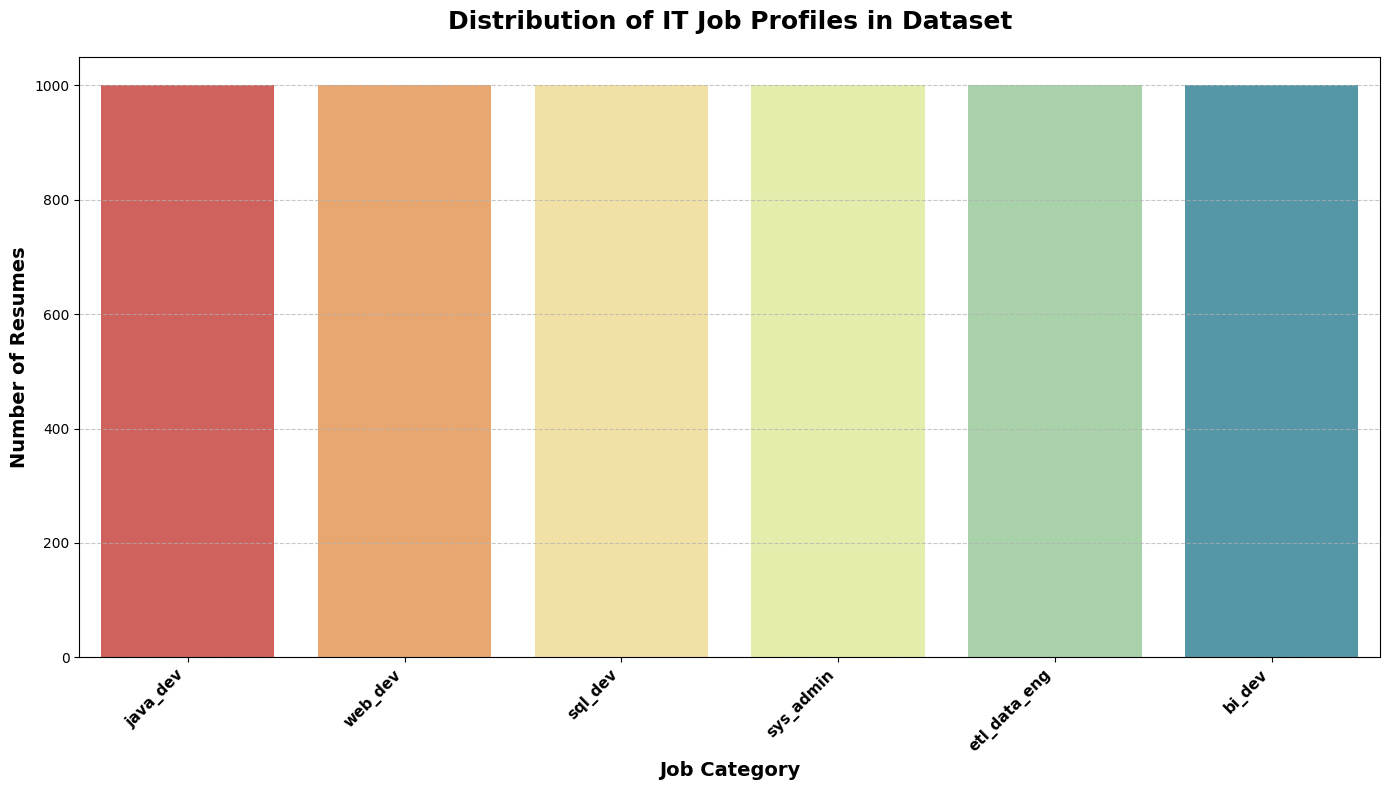

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 8))

ax = sns.countplot(data=df3, x='job_title', hue='job_title', palette='Spectral', legend=False)

plt.xticks(rotation=45, ha='right', fontsize=11, fontweight='bold')

plt.title('Distribution of IT Job Profiles in Dataset', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Job Category', fontsize=14, fontweight='bold')
plt.ylabel('Number of Resumes', fontsize=14, fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()

plt.show()

**third dataset**

---



هاي داتا اصلا كانت جدول

In [ ]:
import kagglehub
import pandas as pd
import os

# تحميل الداتا
path = kagglehub.dataset_download("souptikghosh/resume-dataset")

# عرض الملفات
print(os.listdir(path))

# قراءة CSV
df4_temp = pd.read_csv(path + "/resume_dataset_2.csv", encoding='latin-1')

# عرض البيانات
print('...........................')

# تغيير اسم العمود
df4_temp.rename(columns={
    'Years_Experience': 'experience_years',
    'Job_Role': 'job_title',
    'Resume_Text': 'resume'
}, inplace=True)

df4_temp['clean_resume'] = ''
df4_temp['experience_years'] = df4_temp['experience_years'].fillna(0).astype(float)
df4_temp['job_title'] = df4_temp['job_title'].fillna('').astype(str)
df4_temp['resume'] = df4_temp['resume'].fillna('').astype(str)
# Assign processed data to df4
df4 = df4_temp[['job_title', 'resume', 'experience_years']]

df4.columns
df4.head()

100%|██████████| 56.0k/56.0k [00:00<00:00, 2.04MB/s]

Extracting files...
['resume_dataset_2.csv']
...........................


,job_title,resume,experience_years
0,Data Scientist,\n Name: Tara Gonzalez\n Email: ...,3.0
1,Data Scientist,\n Name: Jared Quinn\n Email: ma...,6.0
2,Data Scientist,\n Name: Jane Woods\n Email: phy...,5.0
3,Data Scientist,\n Name: Julie Chambers\n Email:...,0.0
4,Data Scientist,\n Name: Tonya Campbell\n Email:...,2.0


In [ ]:
df4["job_title"].value_counts()

,count
job_title,
Software Engineer,342
HR Executive,130
Data Scientist,124
Marketing Manager,112
Financial Analyst,107


In [ ]:
it_mapping={"Data Scientist":"Data Science","Software Engineer":"Software Engineer"}
df4 = df4[df4["job_title"].isin(it_mapping.keys())]
df4.head()

,job_title,resume,experience_years
0,Data Scientist,\n Name: Tara Gonzalez\n Email: ...,3.0
1,Data Scientist,\n Name: Jared Quinn\n Email: ma...,6.0
2,Data Scientist,\n Name: Jane Woods\n Email: phy...,5.0
3,Data Scientist,\n Name: Julie Chambers\n Email:...,0.0
4,Data Scientist,\n Name: Tonya Campbell\n Email:...,2.0


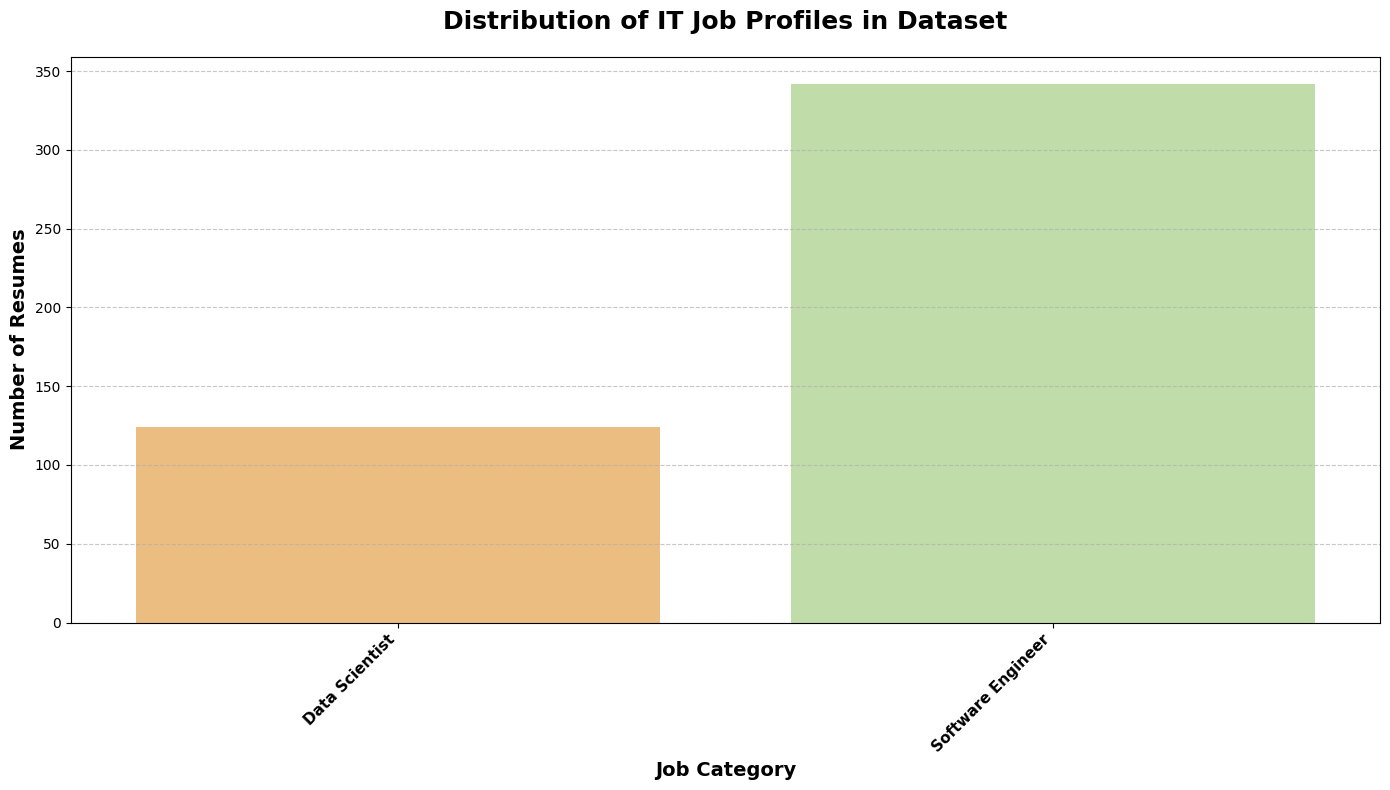

In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 8))

ax = sns.countplot(data=df4, x='job_title', hue='job_title', palette='Spectral', legend=False)

plt.xticks(rotation=45, ha='right', fontsize=11, fontweight='bold')

plt.title('Distribution of IT Job Profiles in Dataset', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Job Category', fontsize=14, fontweight='bold')
plt.ylabel('Number of Resumes', fontsize=14, fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()

plt.show()

**four_dataset**

---



In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("nikitagupta1812/resume-dataset")

print("Path to dataset files:", path)

100%|██████████| 624k/624k [00:00<00:00, 1.36MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/nikitagupta1812/resume-dataset/versions/1


In [ ]:
import pandas as pd
import os


df5 = pd.read_csv(os.path.join(path,'Resume_Screening_Dataset_50000.csv'))

print(df5.shape)
df5.head()

(50000, 11)


,Candidate_ID,Age,Gender,Degree,Specialization,Skills,Experience_Years,Projects_Count,Certifications,Expected_Salary_LPA,Resume_Shortlisted
0,1,38,Female,M.Tech,Computer Science,"ML, Python, SQL",8.3,6,Azure,22.7,Yes
1,2,22,Female,B.Tech,Data Science,"Java, OOP",11.3,5,NPTEL,12.9,Yes
2,3,20,Female,MBA,Mechanical,"C++, DSA",0.7,7,NPTEL,19.3,No
3,4,21,Female,MBA,Computer Science,"Python, SQL",6.6,10,Google Data,4.6,Yes
4,5,32,Male,M.Sc,Mechanical,"C++, DSA",9.2,1,AWS,26.2,No


In [ ]:
df5["Specialization"].value_counts()

,count
Specialization,
IT,8410
Electronics,8362
Mechanical,8345
Data Science,8329
AI,8291
Computer Science,8263


In [ ]:
import pandas as pd

# 1️⃣ فلترة تخصصات IT
it_keywords = "IT|Computer Science|Data Science|AI"

df_it = df5[df5["Specialization"].str.contains(it_keywords, case=False, na=False)]

# 2️⃣ إنشاء DataFrame جديد فيه 3 أعمدة فقط
df_new = pd.DataFrame()

df_new["job_title"] = df_it["Specialization"]

df_new["resume"] = (
    "Skills: " + df_it["Skills"].astype(str) +
    " | Projects: " + df_it["Projects_Count"].astype(str) +
    " | Certifications: " + df_it["Certifications"].astype(str) +
    " | Degree: " + df_it["Degree"].astype(str)
)

df_new["experience_years"] = df_it["Experience_Years"]

# 3️⃣ عرض النتيجة
df_new.head()

,job_title,resume,experience_years
0,Computer Science,"Skills: ML, Python, SQL | Projects: 6 | Certif...",8.3
1,Data Science,"Skills: Java, OOP | Projects: 5 | Certificatio...",11.3
3,Computer Science,"Skills: Python, SQL | Projects: 10 | Certifica...",6.6
6,IT,"Skills: Excel, PowerBI | Projects: 1 | Certifi...",9.5
8,Data Science,"Skills: Cloud, AWS, Azure | Projects: 10 | Cer...",6.2


In [ ]:
df_new.shape

(33293, 3)

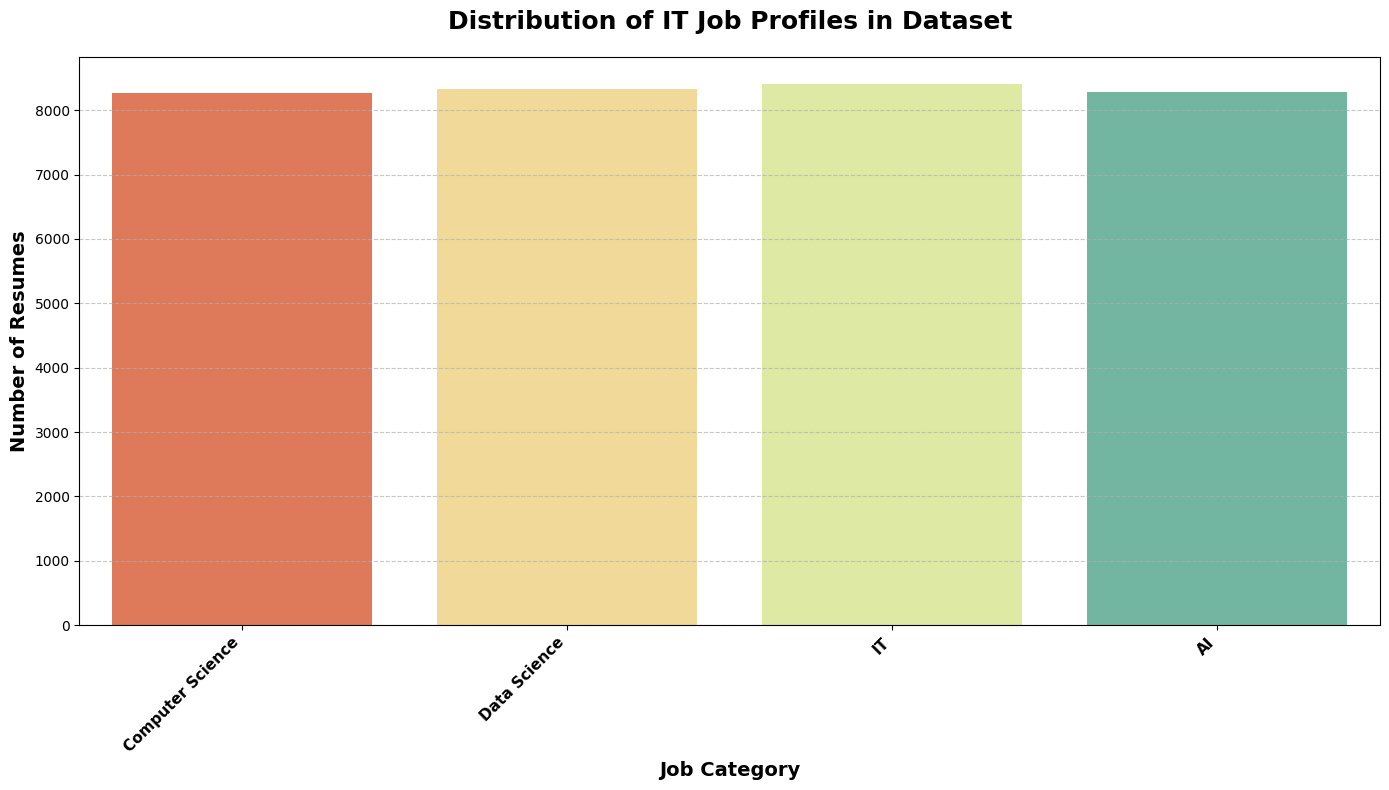

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 8))

ax = sns.countplot(data=df_new, x='job_title', hue='job_title', palette='Spectral', legend=False)

plt.xticks(rotation=45, ha='right', fontsize=11, fontweight='bold')

plt.title('Distribution of IT Job Profiles in Dataset', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Job Category', fontsize=14, fontweight='bold')
plt.ylabel('Number of Resumes', fontsize=14, fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()

plt.show()

**6_dataset**

---



In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("amaankhan24/resume-dataset")

print("Path to dataset files:", path)
print(os.listdir(path))

100%|██████████| 673k/673k [00:00<00:00, 3.33MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/amaankhan24/resume-dataset/versions/1
['Combined_Tech_and_NonTech_Category_Resume.csv']


In [ ]:
import os
df6= pd.read_csv(os.path.join(path,'Combined_Tech_and_NonTech_Category_Resume.csv'))
df6.head()

,Unnamed: 0,Category,Resume
0,0,Database Administrator,"Proficient in Optimization, Cloud Databases, S..."
1,1,Database Administrator,"Proficient in Database Management, Troubleshoo..."
2,2,Cybersecurity Analyst,"Proficient in Penetration Testing, Incident Re..."
3,3,Software Engineer,"Proficient in Software Development, Java, Pyth..."
4,4,Machine Learning Engineer,"Proficient in Python, Data Science, Data Analy..."


In [ ]:
df6["Category"].value_counts().to_string()

'Category\nMechanical Engineer                254\nOperations Manager                 249\nPersonal Trainer                   226\nCivil Engineer                     223\nUrban Planner                      220\nBiomedical Engineer                220\nConstruction Manager               215\nRobotics Engineer                  214\nBusiness Analyst                   213\nPilot                              209\nMachine Learning Engineer          208\nWeb Developer                      207\nFinancial Analyst                  206\nSystems Analyst                    203\nEnvironmental Scientist            203\nCreative Director                  203\nData Analyst                       202\nChef                               202\nHR Specialist                      201\nAI Researcher                      201\nEvent Planner                      201\nPhysician                          201\nSales Representative               199\nSupply Chain Manager               199\nAccountant                   

In [ ]:
# 1️⃣ فلترة وظائف IT
it_jobs = [
    "Software Engineer",
    "Web Developer",
    "Data Analyst",
    "Machine Learning Engineer",
    "AI Researcher",
    "Cybersecurity Analyst",
    "Systems Analyst",
    "Database Administrator",
    "Cloud Architect",
    "Network Security Engineer",
    "Python Developer",
    "Java Developer",
    "ETL Developer",
    "DotNet Developer"
]

df6= df6[df6["Category"].isin(it_jobs)]

df6 = df6.rename(columns={"Category": "job_title"})
df6 = df6.iloc[:, 1:]
# 3️⃣ عرض النتيجة
df6.head()

,job_title,Resume
0,Database Administrator,"Proficient in Optimization, Cloud Databases, S..."
1,Database Administrator,"Proficient in Database Management, Troubleshoo..."
2,Cybersecurity Analyst,"Proficient in Penetration Testing, Incident Re..."
3,Software Engineer,"Proficient in Software Development, Java, Pyth..."
4,Machine Learning Engineer,"Proficient in Python, Data Science, Data Analy..."


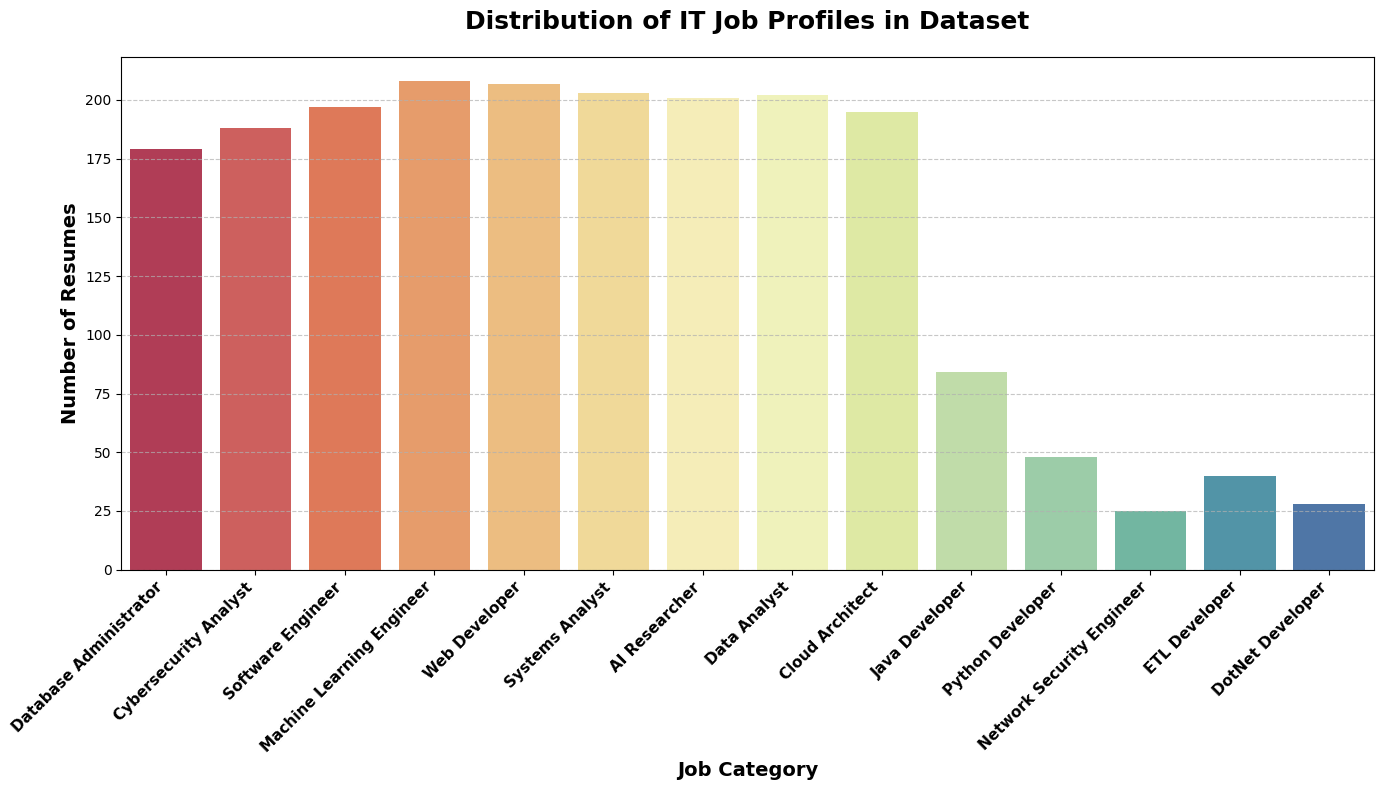

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 8))

ax = sns.countplot(data=df6, x='job_title', hue='job_title', palette='Spectral', legend=False)

plt.xticks(rotation=45, ha='right', fontsize=11, fontweight='bold')

plt.title('Distribution of IT Job Profiles in Dataset', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Job Category', fontsize=14, fontweight='bold')
plt.ylabel('Number of Resumes', fontsize=14, fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()

plt.show()

7dataset

In [ ]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("kilyfaa/sintesis-resume-dataset")

print("Path to dataset files:", path)
print(os.listdir(path))

100%|██████████| 18.3M/18.3M [00:01<00:00, 14.3MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/kilyfaa/sintesis-resume-dataset/versions/1
['preprocessed_dataset.csv']


In [ ]:
import pandas as pd
import os


df7 = pd.read_csv(os.path.join(path,'preprocessed_dataset.csv'))
df7['category'].value_counts()
df7.head()

,category,text_cv
0,accountant,education\r\nomba - executive leadership unive...
1,accountant,"howard gerrard\r\naccountant\r\ndeyjob.com, bi..."
2,accountant,kevin frank\r\nsenior accountant\r\ninfo@resum...
3,accountant,place of birth\r\nnationality\r\nolivia ogilvy...
4,accountant,"stephen greet, cpa\r\nsenior accountant\r\nthr..."


In [ ]:
it_categories = [
    "java developer",
    "sql developer",
    "dotnet developer",
    "web designing",
    "sap developer",
    "data science",
    "etl developer",
    "devops",
    "information technology",
    "database",
    "python developer",
    "react developer",

    "network security engineer",
    "testing"
]
df7= df7[df7["category"].isin(it_categories)]
df7 = df7.rename(columns={
    "category": "job_title",
    "test": "resume"
})
df7.shape

(4145, 2)

In [ ]:
df7.head()

,job_title,text_cv
867,data science,diana dawa\r\ndata scientist\r\ndata scientist...
868,data science,resume objective\r\ndata scientist with 5+ yea...
869,data science,natasha holloway\r\n+1-988-701-2005 @natashaho...
870,data science,wenzhe(evelyn) xu\r\n217-417-9270 | wxu23@illi...
871,data science,first last\r\ndata scientist\r\ndata scientist...


**dataset_8**

In [ ]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("wahib04/multilabel-resume-dataset")

print("Path to dataset files:", path)
print(os.listdir(path))

100%|██████████| 59.7M/59.7M [00:02<00:00, 28.4MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/wahib04/multilabel-resume-dataset/versions/1
['data.csv']


In [ ]:
import pandas as pd
import os


df8 = pd.read_csv(os.path.join(path,'data.csv'))

df8.head()


,Resume,Label
0,Database Administrator Database Administrator ...,Database_Administrator
1,Database Administrator Database Administrator ...,Database_Administrator
2,Oracle Database Administrator Oracle Database ...,Database_Administrator
3,Amazon Redshift Administrator and ETL Develope...,Database_Administrator
4,Scrum Master Scrum Master Scrum Master Richmon...,Database_Administrator


In [ ]:
df8['Label'].value_counts().to_string()

'Label\nSystems_Administrator                                                                                                              2349\nProject_manager                                                                                                                    2339\nDatabase_Administrator                                                                                                             2225\nSoftware_Developer                                                                                                                 1991\nWeb_Developer,Software_Developer                                                                                                   1896\nPython_Developer,Software_Developer                                                                                                1738\nSecurity_Analyst                                                                                                                   1563\nNetwork_Administrator            

In [ ]:
# define IT keywords
it_keywords = [

    "database_administrator",
    "software_developer",
    "web_developer",
    "python_developer",
    "security_analyst",
    "network_administrator"
]

# Rename 'Label' column to 'job_title'
df8.rename(columns={'Label': 'job_title','Resume':'resume'}, inplace=True)

# normalize text
df8['job_title'] = df8['job_title'].str.lower()

# split multi-label rows
df8['job_title'] = df8['job_title'].str.split(',')

df8 = df8.explode('job_title')

# clean spaces
df8['job_title'] = df8['job_title'].str.strip()

# filter only IT jobs
it_df8 = df8[df8['job_title'].isin(it_keywords)]

# check distribution
it_df8['job_title'].value_counts()

,count
job_title,
software_developer,15013
web_developer,6594
network_administrator,4460
database_administrator,3299
security_analyst,3022
python_developer,2836


***`combain all data `***

---



In [ ]:
import pandas as pd

# 1. تجهيز البيانات من المصدر الأول (PDFs)
# نختار فقط التخصصات التقنية من البيانات المستخرجة من الملفات
it_categories_pdf_data = ["INFORMATION-TECHNOLOGY"]
df_it_pdf = df[df["job_title"].isin(it_categories_pdf_data)].copy()

# 2. توحيد أسماء الأعمدة في الجداول المختلفة لضمان الدمج الصحيح
if 'Resume' in df6.columns:
    df6.rename(columns={'Resume': 'resume'}, inplace=True)

if 'text_cv' in df7.columns:
    df7.rename(columns={'text_cv': 'resume'}, inplace=True)
if 'Resume' in it_df8.columns:
    df6.rename(columns={'Resume': 'resume'}, inplace=True)

# 3. قائمة الجداول السبعة المراد دمجها
# df_it_pdf (المصدر 1), df2, df3, df4, df_new (المصدر 5), df6, df7
dfs_to_concat = [df_it_pdf, df2, df3, df4, df_new, df6, df7,it_df8]

# 4. عملية الدمج (Concatenation)
# ignore_index=True لإعادة ترتيب الأسطر من الصفر
df_all = pd.concat(dfs_to_concat, ignore_index=True)

# 5. تنظيف عمود سنوات الخبرة
# تحويل العمود لرقمي، ومعالجة القيم المفقودة (NaN) بوضع صفر مؤقتاً
df_all['experience_years'] = pd.to_numeric(df_all['experience_years'], errors='coerce').fillna(0)

print(df_all.shape)

(81813, 3)


In [ ]:
df_all.head()

,job_title,resume,experience_years
0,INFORMATION-TECHNOLOGY,DATABASE PROGRAMMER/ANALYST (.NET DEVELOPER) S...,0.0
1,INFORMATION-TECHNOLOGY,SENIOR VICE PRESIDENT OF GLOBAL INFORMATION TE...,0.0
2,INFORMATION-TECHNOLOGY,DIRECTOR OF INFORMATION TECHNOLOGY Executive P...,0.0
3,INFORMATION-TECHNOLOGY,INFORMATION TECHNOLOGY INTERN (TEST AUTOMATION...,0.0
4,INFORMATION-TECHNOLOGY,INFORMATION TECHNOLOGY SPECIALIST Professional...,0.0


befor cleaning i will extract the year_expersce

---



وكككككك هون عملت كود بطلع السنوات الخبره من النص بجيمع اشكال يلي ممكن تيجيها مثلاااOver twenty years of experience in IT", "Over 10+ years of professional experience", "Worked from 1990-2050", "3+ years in data science", "9 months of internship رح تتعامل مع كل هدول واطلعهم تتخيلواااااااا يس انا ذكيعه ما شاءلله علي " word2number هاي المكتبه مشان تحل مشكله الارقام لو كانت مكتوبه مثلا one------>1 بتحوله لرقم بس

In [ ]:
import re
from datetime import datetime

import re
from datetime import datetime

def extract_clean_experience_years(text):
    if not text or str(text).lower() == 'nan':
        return 0.0

    # 1. تحويل النص لصغير وقصه عند أول ظهور لقسم غير مهني (لإزالة الـ 2.8)
    text_lower = str(text).lower()
    split_keywords = ['activities', 'education', 'awards', 'honor society', 'additional information']

    clean_text = text_lower
    for kw in split_keywords:
        if kw in clean_text:
            clean_text = clean_text.split(kw)[0]
            break

    # 2. البحث عن التواريخ في الجزء المهني فقط
    date_pattern = re.compile(r'(\d{1,2}/)?(\d{4})\s*(?:to|-|–)\s*(\d{1,2}/)?(\d{4}|current|present|now)')
    found_spans = date_pattern.findall(clean_text)

    worked_months = set()
    current_date = datetime.now()

    for start_m, start_y, end_m, end_y in found_spans:
        try:
            s_year = int(start_y)
            s_month = int(start_m.replace('/', '')) if start_m else 1

            if end_y.lower() in ('current', 'present', 'now'):
                e_year = current_date.year
                e_month = current_date.month
            else:
                e_year = int(end_y)
                e_month = int(end_m.replace('/', '')) if end_m else 12

            # إضافة الشهور للـ Set لمنع التكرار
            for m in range(s_year * 12 + s_month, e_year * 12 + e_month + 1):
                worked_months.add(m)
        except:
            continue

    # إرجاع الرقم فقط
    return round(len(worked_months) / 12, 1)



def apply_smart_extraction(row):
    if row['experience_years'] > 0:
        return row['experience_years']
    return extract_clean_experience_years(str(row['resume']))
df_all["experience_years"] = df_all.apply(apply_smart_extraction, axis=1)
df_all.head()

,job_title,resume,experience_years
0,INFORMATION-TECHNOLOGY,DATABASE PROGRAMMER/ANALYST (.NET DEVELOPER) S...,0.0
1,INFORMATION-TECHNOLOGY,SENIOR VICE PRESIDENT OF GLOBAL INFORMATION TE...,42.4
2,INFORMATION-TECHNOLOGY,DIRECTOR OF INFORMATION TECHNOLOGY Executive P...,20.8
3,INFORMATION-TECHNOLOGY,INFORMATION TECHNOLOGY INTERN (TEST AUTOMATION...,2.7
4,INFORMATION-TECHNOLOGY,INFORMATION TECHNOLOGY SPECIALIST Professional...,0.0


# Cleaning Data:

1.  URLs
2. hashtags
1.   mention
2. special letters
1. punctuations




---





In [ ]:
import re

import re

def clean_text(txt):
    txt = str(txt)

    # 🔥 URLs
    txt = re.sub(r'http\S+|www\S+', ' ', txt)

    # 🔥 emails
    txt = re.sub(r'\S+@\S+', ' ', txt)

    # 🔥 mentions (social media)
    txt = re.sub(r'@\w+', ' ', txt)

    # 🔥 hashtags (remove # but keep word)
    txt = re.sub(r'#(\w+)', r'\1', txt)

    # 🔥 RT / CC noise
    txt = re.sub(r'\bRT\b|\bcc\b', ' ', txt)

    # ❌ remove only meaningless punctuation
    # ✔ KEEP: + # . _ / - (important for skills like C++, .NET, node.js)
    txt = re.sub(r'[!"$%&\'()*,:;<=>?@\[\]^`{|}~]', ' ', txt)

    # 🔥 fix weird encoding (optional but very useful)
    txt = txt.encode('utf-8', errors='ignore').decode('utf-8')

    # 🔥 remove non-ascii junk
    txt = re.sub(r'[^\x00-\x7f]', ' ', txt)

    # 🔥 remove standalone numbers ONLY
    txt = re.sub(r'(?<!\w)\d+(?!\w)', ' ', txt)

    # 🔥 normalize spaces
    txt = re.sub(r'\s+', ' ', txt)

    return txt.lower().strip()

# Re-apply to your dataframe
df_all['cleanresume'] = df_all['resume'].astype(str).apply(clean_text)



✅ keep='first' يعني الاحتفاظ بالصف الأول لكل نص مكرر، وحذف الباقي.
✅ reset_index(drop=True) يعيد ترقيم الصفوف بعد الحذف.

In [ ]:
# إزالة الصفوف التي تحتوي على نفس النص في cleanresume
# لنفترض عندك عمود resume و job_title و experience_years
print("Number of rowsلbefor smart deduplication:", df_all.shape[0])
df_all = df_all.drop_duplicates(subset=['cleanresume', 'job_title','experience_years'], keep='first').reset_index(drop=True)

print("Number of rows after smart deduplication:", df_all.shape[0])

# تحقق
print(df_all.shape)
print(df_all.sample(3))

Number of rowsلbefor smart deduplication: 81813
Number of rows after smart deduplication: 72777
(72777, 4)
                job_title                                             resume  \
43433  software_developer  Front End Developer Front End Developer Front ...   
23914    Computer Science  Skills: Java, OOP | Projects: 2 | Certificatio...   
40452    security_analyst  Guardium Administrator Guardium Administrator ...   

       experience_years                                        cleanresume  
43433              15.4  front end developer front end developer front ...  
23914              10.0  skills java oop projects certifications google...  
40452               7.4  guardium administrator guardium administrator ...  


***`normlize name `***

In [ ]:
df_all['job_title'].value_counts()

,count
job_title,
software_developer,14517
IT,7239
Data Science,7164
AI,7059
Computer Science,7034
web_developer,6277
network_administrator,4181
database_administrator,3243
security_analyst,2957


In [ ]:
# 1. CLEAN TEXT
df_all['job_title'] = (
    df_all['job_title']
    .str.lower()
    .str.strip()
    .str.replace(' ', '_', regex=False)
    .str.replace('-', '_', regex=False)
)

# Unify key duplicates
df_all['job_title'] = df_all['job_title'].replace({
    "java_developer":           "java_dev",
    "python_developer":         "python_dev",
    "web_developer":            "web_dev",
    "sql_developer":            "sql_dev",
    "etl_developer":            "etl_data_eng",
    "machine_learning_engineer":"ml_engineer",
    "data_scientist":           "data_science",
})

# 2. MAP TO GROUPS
mapping = {
    # 💻 Software Engineering
    "software_developer":   "software_engineering",
    "software_engineer":    "software_engineering",
    "java_dev":             "software_engineering",
    "dotnet_developer":     "software_engineering",
    "react_developer":      "software_engineering",
    "python_dev":           "software_engineering",


    # 📊 Data & AI
    "data_science":         "data_ai",
    "data_analyst":         "data_ai",
    "ai":                   "data_ai",
    "ai_researcher":        "data_ai",
    "ml_engineer":          "data_ai",   # ✅ use renamed key
    "etl_data_eng":         "data_ai",
    "sql_dev":              "data_ai",
    "bi_dev":               "data_ai",
    "hadoop":               "data_ai",
    "database":             "data_ai",

    # 🏢 IT Systems
    "it":                   "it_systems",
    "information_technology":"it_systems",
    "computer_science":     "it_systems",
    "systems_analyst":      "it_systems",
    "sys_admin":            "it_systems",
    "project_manager":      "it_systems",

    # 🔐 Infrastructure & Security
     # ✅ use renamed key
    "web_designing":        "infrastructure",
    "network_administrator":"infrastructure",
    "network_security_engineer": "infrastructure",
    "security_analyst":     "infrastructure",
    "cybersecurity_analyst":"infrastructure",

    "database_administrator":"infrastructure",
    "cloud_architect":      "infrastructure",
    "devops":               "infrastructure",
    "devops_engineer":      "infrastructure",
    "testing":              "infrastructure",
    "automation_testing":   "infrastructure",
    "sap_developer":        "infrastructure",
    "web_dev":              "infrastructure",
}

df_all['job_group'] = df_all['job_title'].replace(mapping)

# 3. CHECK UNMAPPED (fixed)
expected_groups = {"software_engineering", "data_ai", "it_systems", "infrastructure"}
unmapped = df_all[~df_all['job_group'].isin(expected_groups)]
print("Unmapped values:")
print(unmapped['job_title'].value_counts())

# 4. FINAL CHECK
print(df_all['job_group'].value_counts())

Unmapped values:
Series([], Name: count, dtype: int64)
job_group
infrastructure          19614
software_engineering    19234
data_ai                 18393
it_systems              15536
Name: count, dtype: int64


In [ ]:
expected_groups = {"software_engineering", "data_ai", "it_systems", "infrastructure"}
unmapped = df_all[~df_all['job_group'].isin(expected_groups)]
print("Unmapped values:")
print(unmapped['job_title'].value_counts())

Unmapped values:
Series([], Name: count, dtype: int64)


Series([], dtype: int64)

✔️ هذا يعني:

كل البيانات انصنفت بشكل صحيح 100%
ما في أي job_title ضايع
إحنا ما كنا نعمل “تصنيفات أسماء”
إحنا كنا نعمل:

Grouping حسب طبيعة الشغل الحقيقي في سوق العمل

يعني:
مش “شو اسم الوظيفة”
بل “شو نوع الشغل فعليًا”

🧠 كيف فكرنا بالتقسيم؟

قسمنا البيانات حسب 4 عائلات وظيفية كبيرة 👇

💻 1. software_engineering
شو دخل فيها؟

أي شخص “يبني برامج أو تطبيقات”

أمثلة:
software_developer
java_dev / python_dev
dotnet / react
web_developer
🎯 ليش جمّعناهم؟

لأنهم كلهم:

يكتبوا كود ويب/برمجيات/أنظمة

✔ نفس المهارة الأساسية = Programming

📊 2. data_ai
شو دخل فيها؟

أي شخص “يحلل بيانات أو يبني نماذج ذكاء اصطناعي”

أمثلة:
data_science
data_analyst
machine_learning_engineer
ai_researcher
sql / etl / bi
🎯 ليش؟

لأنهم كلهم:

يشتغلوا على البيانات (مش بناء تطبيقات)

✔ نفس المجال = Data Pipeline + ML + Analytics

🏢 3. it_systems
شو دخل فيها؟

أشخاص يديروا الأنظمة والبنية الإدارية

أمثلة:
systems_administrator
sys_admin
project_manager
information_technology
computer_science
🎯 ليش؟

لأنهم:

مش بيبنوا منتجات، بل يديروا بيئة العمل

✔ نفس الدور = إدارة وتشغيل نظم

🔐 4. infrastructure
شو دخل فيها؟

كل شيء متعلق بـ:

الشبكات
السيرفرات
الأمن
DevOps
أمثلة:
network_admin
cybersecurity
cloud_architect
devops
database_admin
testing
🎯 ليش؟

لأنهم:

مسؤولين عن “البيئة اللي يشتغل عليها النظام”

✔ نفس المجال = تشغيل + حماية + بنية تحتية

⚖️ ليش هذا التقسيم منطقي؟

لأنه في الحقيقة في الشركات:

القسم	الوظيفة
Software	بناء المنتج
Data/AI	تحليل واتخاذ قرار
IT Systems	إدارة النظام
Infrastructure	تشغيل وحماية النظام
📌 أهم نقطة فهميها

إحنا ما قسمنا حسب:
❌ أسماء الوظائف
✔ قسمنا حسب نوع المهارة الأساسية

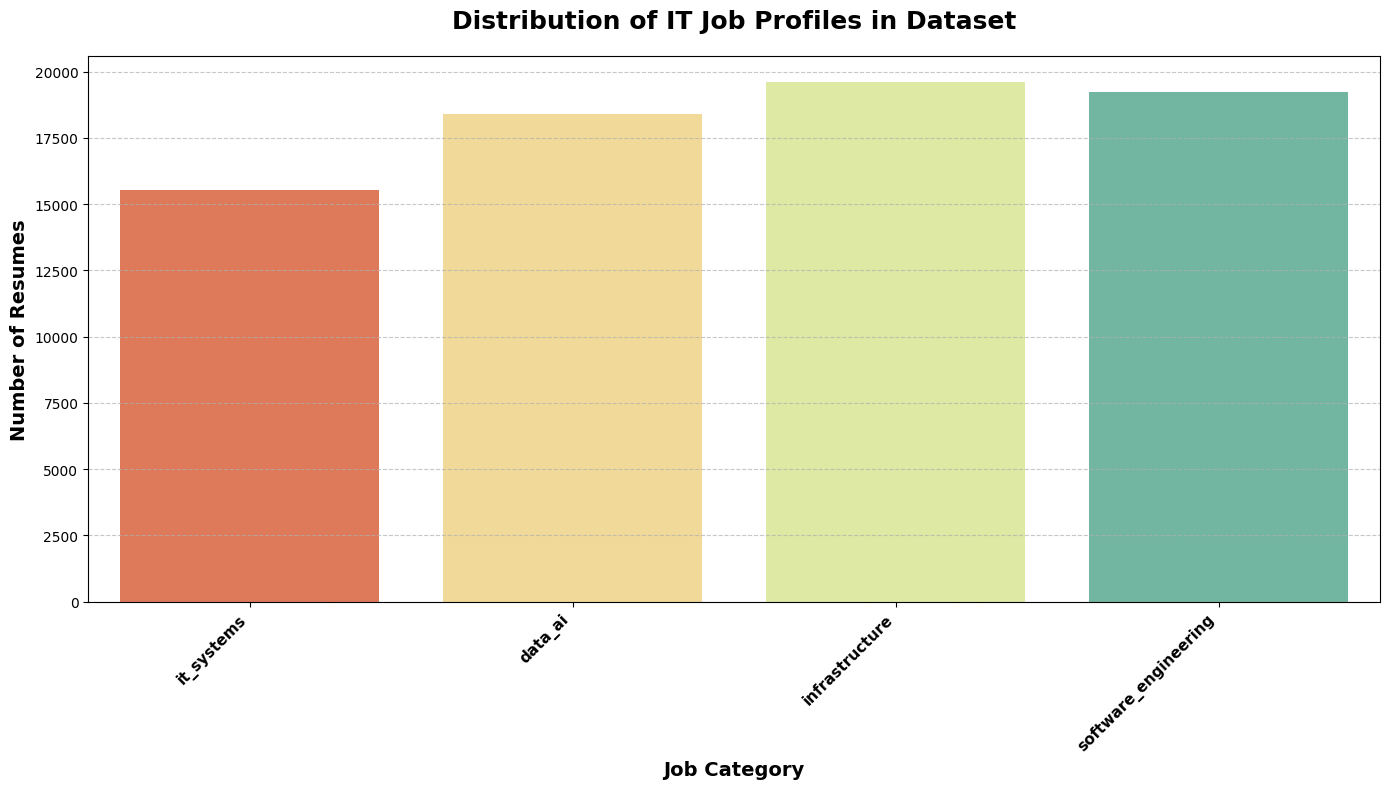

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 8))

ax = sns.countplot(data=df_all, x='job_group', hue='job_group', palette='Spectral', legend=False)

plt.xticks(rotation=45, ha='right', fontsize=11, fontweight='bold')

plt.title('Distribution of IT Job Profiles in Dataset', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Job Category', fontsize=14, fontweight='bold')
plt.ylabel('Number of Resumes', fontsize=14, fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()

plt.show()

In [ ]:
# عد القيم الفارغة في عامود سنوات الخبرة
null_count = df_all['experience_years'].isnull().sum()

print(f"عدد القيم الفارغة (Null) في سنوات الخبرة: {null_count}")

عدد القيم الفارغة (Null) في سنوات الخبرة: 0


In [ ]:
df_all.head()

,job_title,resume,experience_years,cleanresume,job_group
0,information_technology,DATABASE PROGRAMMER/ANALYST (.NET DEVELOPER) S...,0.0,database programmer/analyst .net developer sum...,it_systems
1,information_technology,SENIOR VICE PRESIDENT OF GLOBAL INFORMATION TE...,42.4,senior vice president of global information te...,it_systems
2,information_technology,DIRECTOR OF INFORMATION TECHNOLOGY Executive P...,20.8,director of information technology executive p...,it_systems
3,information_technology,INFORMATION TECHNOLOGY INTERN (TEST AUTOMATION...,2.7,information technology intern test automation ...,it_systems
4,information_technology,INFORMATION TECHNOLOGY SPECIALIST Professional...,0.0,information technology specialist professional...,it_systems


**remove stopword form clean CV**

---



In [ ]:
df_all

,job_title,resume,experience_years,cleanresume,job_group
0,information_technology,DATABASE PROGRAMMER/ANALYST (.NET DEVELOPER) S...,0.0,database programmer/analyst .net developer sum...,it_systems
1,information_technology,SENIOR VICE PRESIDENT OF GLOBAL INFORMATION TE...,42.4,senior vice president of global information te...,it_systems
2,information_technology,DIRECTOR OF INFORMATION TECHNOLOGY Executive P...,20.8,director of information technology executive p...,it_systems
3,information_technology,INFORMATION TECHNOLOGY INTERN (TEST AUTOMATION...,2.7,information technology intern test automation ...,it_systems
4,information_technology,INFORMATION TECHNOLOGY SPECIALIST Professional...,0.0,information technology specialist professional...,it_systems
...,...,...,...,...,...
72772,web_dev,UI Developer UI Developer UI Developer - Cotiv...,8.4,ui developer ui developer ui developer - cotiv...,infrastructure
72773,web_dev,"Web Developer Web Developer Los Angeles, CA Wo...",0.0,web developer web developer los angeles ca wor...,infrastructure
72774,software_developer,"Web Developer Web Developer Los Angeles, CA Wo...",0.0,web developer web developer los angeles ca wor...,software_engineering
72775,software_developer,Sr. Software Engineer Sr. Software Engineer Sr...,7.4,sr. software engineer sr. software engineer sr...,software_engineering


In [ ]:

output_path = '/content/_finalnewwwww_cleaned_resumes.csv'

# احفظ DataFrame
df_all.to_csv(output_path, index=False)
print(f"Saved to {output_path}")

Saved to /content/_finalnewwwww_cleaned_resumes.csv


In [ ]:
from google.colab import files

files.download(output_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **job_handling**

In [ ]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("adityarajsrv/job-descriptions-2025-tech-and-non-tech-roles")

print("Path to dataset files:", path)
print(os.listdir(path))

100%|██████████| 203k/203k [00:00<00:00, 727kB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/adityarajsrv/job-descriptions-2025-tech-and-non-tech-roles/versions/1
['job_dataset.json', 'job_dataset.csv']


In [ ]:
import pandas as pd
import os
import pandas as pd
import os


job=pd.read_csv(os.path.join(path,'job_dataset.csv'))
job.head()

,JobID,Title,ExperienceLevel,YearsOfExperience,Skills,Responsibilities,Keywords
0,NET-F-001,.NET Developer,Fresher,0-1,C#; VB.NET basics; .NET Framework; .NET Core f...,Assist in coding and debugging applications; L...,.NET; C#; ASP.NET MVC; Entity Framework; SQL S...
1,NET-F-002,.NET Developer,Fresher,0-1,C#; .NET Framework basics; ASP.NET; Razor; HTM...,Write simple C# programs under guidance; Suppo...,.NET; C#; ASP.NET MVC; Entity Framework; SQL S...
2,NET-F-003,.NET Developer,Fresher,0-1,C#; VB.NET basics; .NET Core; ASP.NET MVC; HTM...,Contribute to development of small modules; As...,.NET; C#; ASP.NET MVC; SQL Server; Entity Fram...
3,NET-F-004,.NET Developer,Fresher,0-1,C#; .NET Framework; ASP.NET basics; SQL Server...,Support in software design documentation; Assi...,.NET; C#; SQL Server; Entity Framework; ASP.NET
4,NET-F-005,.NET Developer,Fresher,0-1,C#; ASP.NET; MVC; Entity Framework basics; SQL...,Learn to design and build ASP.NET applications...,.NET; C#; ASP.NET MVC; Entity Framework; SQL S...


In [ ]:
job["Title"].unique()

array(['.NET Developer', 'AI Engineer - Fresher',
       'AI Engineer - Experienced', nan, 'AI Prompt Engineer',
       'Android Developer Intern', 'Junior Android Developer',
       'Android App Developer Trainee', 'Entry-level Android Developer',
       'Associate Android Developer', 'Trainee Android App Developer',
       'Junior Android Engineer', 'Android Development Intern',
       'Android Developer Trainee', 'Android Developer',
       'Senior Android Developer', 'Lead Android Engineer',
       'Android Solutions Engineer', 'Principal Android Developer',
       'Android Tech Lead', 'Senior Android Engineer',
       'Android Architect', 'Android Solutions Architect',
       'Principal Android Engineer', 'AR/VR Developer',
       'Backend Developer - Entry Level',
       'Backend Developer - Experienced', 'Big Data Specialist',
       'Blockchain Developer', 'Business Analyst', 'BI Analyst - Fresher',
       'BI Analyst - Experienced', 'Cloud Architect',
       'Cloud Solutions A

In [ ]:
job.shape

(1068, 7)

In [ ]:
job['Title'].value_counts()

,count
Title,
.NET Developer,20
AI Prompt Engineer,20
AR/VR Developer,20
Business Analyst,20
Data Engineer,20
...,...
Senior Interaction Designer,1
UX Consultant,1
UX Strategist,1


In [ ]:
import pandas as pd
import re

# 1. إنشاء الجدول المستقل


# 2. المسمى الوظيفي
job['job_title'] = job['Title'].str.strip()

# 3. معالجة "فترة" سنوات الخبرة (Year of Experience)
import re
import numpy as np

def clean_experience(exp):
    if exp is None or str(exp).strip() == "nan":
        return 0

    exp = str(exp).strip()

    # ┅ Case 1: range (0-1)
    if "-" in exp:
        try:
            start, end = exp.split("-")
            return (float(start) + float(end)) / 2
        except:
            return 0

    # ┅ Case 2: "3+"
    if "+" in exp:
        try:
            return float(exp.replace("+", "").strip())
        except:
            return 0

    # ┅ Case 3: normal number
    try:
        return float(exp)
    except:
        return 0

# Apply the cleaning function to create 'year_exper'
job['year_exper'] = job['YearsOfExperience'].apply(clean_experience)

# 4. دمج النصوص في عمود واحد (job_text)
job['job_text'] = (
    "skills: " + job['Skills'].fillna('') +
    " responsibilities: " + job['Responsibilities'].fillna('') +
    " keywords: " + job['Keywords'].fillna('')
)

# Drop original source columns
job.drop(columns=['Title', 'YearsOfExperience', 'Skills', 'Responsibilities', 'Keywords','ExperienceLevel',"JobID"], inplace=True)

# عرض النتيجة

In [ ]:

job.head()

,job_title,year_exper,job_text
0,.NET Developer,0.5,skills: C#; VB.NET basics; .NET Framework; .NE...
1,.NET Developer,0.5,skills: C#; .NET Framework basics; ASP.NET; Ra...
2,.NET Developer,0.5,skills: C#; VB.NET basics; .NET Core; ASP.NET ...
3,.NET Developer,0.5,skills: C#; .NET Framework; ASP.NET basics; SQ...
4,.NET Developer,0.5,skills: C#; ASP.NET; MVC; Entity Framework bas...


clean the text of job(tha same of resume)

In [ ]:
import re

import re

def clean_text(txt):
    txt = str(txt)

    # 🔥 URLs
    txt = re.sub(r'http\S+|www\S+', ' ', txt)

    # 🔥 emails
    txt = re.sub(r'\S+@\S+', ' ', txt)

    # 🔥 mentions (social media)
    txt = re.sub(r'@\w+', ' ', txt)

    # 🔥 hashtags (remove # but keep word)
    txt = re.sub(r'#(\w+)', r'\1', txt)

    # 🔥 RT / CC noise
    txt = re.sub(r'\bRT\b|\bcc\b', ' ', txt)

    # ❌ remove only meaningless punctuation
    # ✔ KEEP: + # . _ / - (important for skills like C++, .NET, node.js)
    txt = re.sub(r'[!"$%&\'()*,:;<=>?@\[\]^`{|}~]', ' ', txt)

    # 🔥 fix weird encoding (optional but very useful)
    txt = txt.encode('utf-8', errors='ignore').decode('utf-8')

    # 🔥 remove non-ascii junk
    txt = re.sub(r'[^\x00-\x7f]', ' ', txt)

    # 🔥 remove standalone numbers ONLY
    txt = re.sub(r'(?<!\w)\d+(?!\w)', ' ', txt)

    # 🔥 normalize spaces
    txt = re.sub(r'\s+', ' ', txt)

    return txt.lower().strip()



In [ ]:
import re

import re

def clean_job_title(title):
    title = str(title).lower()

    # 🔥 خطوة مهمة جداً: توحيد كل المسافات
    title = re.sub(r'\s+', ' ', title)

    # 🔥 توحيد الرموز قبل أي شيء
    title = title.replace('-', ' ')
    title = title.replace('/', ' ')
    title = title.replace('.', ' ')

    title = re.sub(r'\s+', ' ', title)  # مرة ثانية بعد الرموز

    # 🔥 إزالة مستويات الخبرة (بدون \b)
    title = re.sub(r'entry\s*level|mid\s*level|experienced|internship|intern|trainee|fresher', '', title)

    title = re.sub(r'junior|jr|senior|sr|lead|principal', '', title)

    # 🔥 حذف الأرقام
    title = re.sub(r'\d+', '', title)

    # تنظيف نهائي
    title = re.sub(r'\s+', ' ', title).strip()

    return title
job['job_title_clean'] = job['job_title'].apply(clean_job_title)

job_profiles = job.groupby("job_title_clean").agg({
    "job_text": " ".join,
    "year_exper": "max"
}).reset_index()
job_profiles['clean_text'] = job_profiles['job_text'].apply(clean_text)
job_profiles.head()

,job_title_clean,job_text,year_exper,clean_text
0,ai engineer,skills: Python; Java; C++; R; Supervised/Unsup...,0.0,skills python java c++ r supervised/unsupervis...
1,ai prompt engineer,skills: Python basics; JavaScript basics; Intr...,3.0,skills python basics javascript basics intro t...
2,android app developer,skills: Kotlin; Java; Android Studio; UI/UX Ba...,0.0,skills kotlin java android studio ui/ux basics...
3,android architect,skills: Kotlin; Java; Android Studio; MVVM; Cl...,0.0,skills kotlin java android studio mvvm clean a...
4,android developer,skills: Java; Kotlin; Android Studio; XML; RES...,0.0,skills java kotlin android studio xml rest api...


In [ ]:
job_profiles["job_title_clean"].unique()

array(['ai engineer', 'ai prompt engineer', 'android app developer',
       'android architect', 'android developer', 'android development',
       'android engineer', 'android solutions architect',
       'android solutions engineer', 'android tech', 'ar vr developer',
       'associate android developer', 'associate cloud architect',
       'associate cybersecurity analyst', 'associate ios engineer',
       'associate network engineer', 'associate system engineer',
       'associate ux designer', 'backend developer', 'bi analyst',
       'big data specialist', 'blockchain developer', 'business analyst',
       'cloud', 'cloud architect', 'cloud automation engineer',
       'cloud cost optimization architect', 'cloud devsecops architect',
       'cloud engineer', 'cloud infrastructure architect',
       'cloud infrastructure security architect',
       'cloud migration specialist', 'cloud network engineer',
       'cloud platform architect', 'cloud security analyst',
       'cloud sec

In [ ]:
it_keywords = [
    'developer', 'engineer', 'data', 'ai',
    'machine learning', 'cloud', 'devops',
    'backend', 'frontend', 'python',
    'java', 'net', 'javascript',
     'robotics', 'vr','cybersecurity','cyber','hacker','security','network',
]

df_job = job_profiles[
    job_profiles['job_title_clean'].str.contains('|'.join(it_keywords), case=False, na=False)
].copy()

In [ ]:
df_job['job_title_clean'].unique()

array(['ai engineer', 'ai prompt engineer', 'android app developer',
       'android developer', 'android engineer',
       'android solutions engineer', 'ar vr developer',
       'associate android developer', 'associate cloud architect',
       'associate cybersecurity analyst', 'associate ios engineer',
       'associate network engineer', 'associate system engineer',
       'backend developer', 'big data specialist', 'blockchain developer',
       'cloud', 'cloud architect', 'cloud automation engineer',
       'cloud cost optimization architect', 'cloud devsecops architect',
       'cloud engineer', 'cloud infrastructure architect',
       'cloud infrastructure security architect',
       'cloud migration specialist', 'cloud network engineer',
       'cloud platform architect', 'cloud security analyst',
       'cloud security architect', 'cloud solutions architect',
       'cloud solutions associate', 'cyber defense analyst',
       'cybersecurity', 'cybersecurity analyst',
       

In [ ]:
mapping = {

# =========================
# 💻 SOFTWARE ENGINEERING
# =========================
"android app developer": "software_engineering",
"android developer": "software_engineering",
"android engineer": "software_engineering",
"android solutions engineer": "software_engineering",
"android solutions architect": "software_engineering",
"associate android developer": "software_engineering",

"ios app developer": "software_engineering",
"ios application developer": "software_engineering",
"ios developer": "software_engineering",
"ios engineer": "software_engineering",
"ios mobile developer": "software_engineering",
"ios mobile app engineer": "software_engineering",
"ios solutions engineer": "software_engineering",

"backend developer": "software_engineering",
"frontend developer": "software_engineering",
"full stack developer": "software_engineering",
"software developer": "software_engineering",
"software engineer": "software_engineering",
"web developer": "software_engineering",

"java developer": "software_engineering",
"javascript developer": "software_engineering",
"python developer": "software_engineering",
"net developer": "software_engineering",
"swift developer": "software_engineering",

"game developer": "software_engineering",
"fintech engineer": "software_engineering",
"blockchain developer": "software_engineering",
"ar vr developer": "software_engineering",
"iot engineer": "software_engineering",
"robotics engineer": "software_engineering",
"vibe coder": "software_engineering",
"associate ios engineer": "software_engineering",
"graduate ios developer": "software_engineering",

# =========================
# 📊 DATA & AI
# =========================
"ai engineer": "data_ai",
"ai prompt engineer": "data_ai",

"data analyst": "data_ai",
"data analyst data scientist": "data_ai",
"data engineer": "data_ai",
"data science": "data_ai",
"data science associate": "data_ai",
"data science team": "data_ai",
"data scientist": "data_ai",
"big data specialist": "data_ai",
"bi analyst": "data_ai",
"market research analyst": "data_ai",

"machine learning engineer": "data_ai",
"machine learning scientist": "data_ai",
"ml ai engineer": "data_ai",
"ml engineer": "data_ai",
"ml infrastructure engineer": "data_ai",
"associate cybersecurity analyst": "data_ai",

# =========================
# 🏢 IT SYSTEMS
# =========================
"associate system engineer": "it_systems",
"system engineer": "it_systems",
"system engineer automation specialist": "it_systems",
"system engineer cloud & automation": "it_systems",
"system engineer cloud focus": "it_systems",
"system engineer devops integration": "it_systems",
"system engineer monitoring": "it_systems",
"system engineer security": "it_systems",
"system engineer virtualization": "it_systems",

"it support networking focus": "it_systems",
"operations manager": "it_systems",
"project manager": "it_systems",
"business analyst": "it_systems",
"computer science": "it_systems",
"entry level network analyst": "it_systems",


# =========================
# 🔐 INFRASTRUCTURE & SECURITY
# =========================
"cloud": "infrastructure",
"cloud architect": "infrastructure",
"associate cloud architect": "infrastructure",
"enterprise cloud architect": "infrastructure",
"hybrid cloud architect": "infrastructure",
"multi cloud architect": "infrastructure",
"cloud engineer": "infrastructure",
"cloud automation engineer": "infrastructure",
"cloud cost optimization architect": "infrastructure",
"cloud devsecops architect": "infrastructure",
"cloud infrastructure architect": "infrastructure",
"cloud infrastructure security architect": "infrastructure",
"cloud migration specialist": "infrastructure",
"cloud network engineer": "infrastructure",
"cloud platform architect": "infrastructure",
"cloud security analyst": "infrastructure",
"cloud security architect": "infrastructure",
"cloud solutions architect": "infrastructure",
"cloud solutions associate": "infrastructure",

"devops engineer": "infrastructure",
"devops cloud architect": "infrastructure",

"network": "infrastructure",
"network analyst": "infrastructure",
"network engineer": "infrastructure",
"network automation engineer": "infrastructure",
"network operations center (noc) engineer": "infrastructure",
"network security engineer": "infrastructure",
"network support engineer": "infrastructure",
"enterprise network engineer": "infrastructure",
"infrastructure network engineer": "infrastructure",
"telecom & network engineer": "infrastructure",

"cybersecurity": "infrastructure",
"cybersecurity analyst": "infrastructure",
"cybersecurity risk analyst": "infrastructure",
"cybersecurity support analyst": "infrastructure",
"cyber defense analyst": "infrastructure",
"information security analyst": "infrastructure",
"information security specialist": "infrastructure",
"security analyst": "infrastructure",
"soc analyst": "infrastructure",
"ethical hacker": "infrastructure",
"security & network engineer": "infrastructure",

"qa engineer": "infrastructure",
"test automation engineer": "infrastructure",
"software tester (sdet)": "infrastructure",

"site reliability engineer": "infrastructure",
"associate network engineer": "infrastructure",
"graduate network engineer": "infrastructure",
"graduate security analyst": "infrastructure",
}
df_job['job_group'] = df_job['job_title_clean'].replace(mapping)
df_job['job_group'].value_counts()

,count
job_group,
infrastructure,47
software_engineering,31
data_ai,16
it_systems,10


In [ ]:
unmapped = df_job[df_job['job_group'].isna()]
print(unmapped['job_title_clean'].value_counts())

Series([], Name: count, dtype: int64)


In [ ]:
df_job.head()

,job_title_clean,job_text,year_exper,clean_text,job_group
0,ai engineer,skills: Python; Java; C++; R; Supervised/Unsup...,0.0,skills python java c++ r supervised/unsupervis...,data_ai
1,ai prompt engineer,skills: Python basics; JavaScript basics; Intr...,3.0,skills python basics javascript basics intro t...,data_ai
2,android app developer,skills: Kotlin; Java; Android Studio; UI/UX Ba...,0.0,skills kotlin java android studio ui/ux basics...,software_engineering
4,android developer,skills: Java; Kotlin; Android Studio; XML; RES...,0.0,skills java kotlin android studio xml rest api...,software_engineering
6,android engineer,skills: Java; Kotlin; Android Studio; XML; SQL...,0.0,skills java kotlin android studio xml sqlite u...,software_engineering


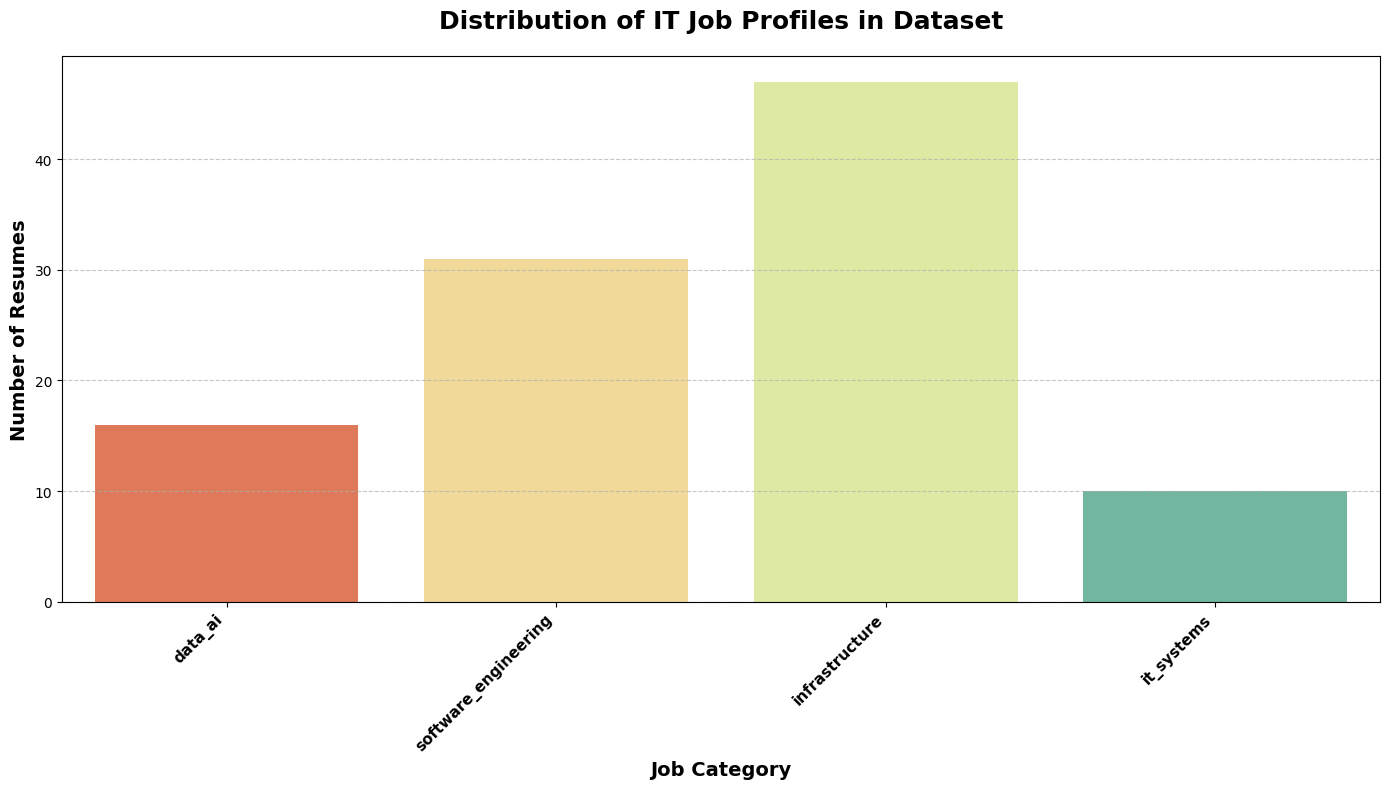

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 8))

ax = sns.countplot(data=df_job, x='job_group', hue='job_group', palette='Spectral', legend=False)

plt.xticks(rotation=45, ha='right', fontsize=11, fontweight='bold')

plt.title('Distribution of IT Job Profiles in Dataset', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Job Category', fontsize=14, fontweight='bold')
plt.ylabel('Number of Resumes', fontsize=14, fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()

plt.show()

In [ ]:

output_path = '/content/_finalnewwwww_cleaned_job.csv'

# احفظ DataFrame
df_all.to_csv(output_path, index=False)
print(f"Saved to {output_path}")

Saved to /content/_finalnewwwww_cleaned_job.csv


In [ ]:
from google.colab import files

files.download(output_path)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
print(df_all)

                    job_title  \
0      information_technology   
1      information_technology   
2      information_technology   
3      information_technology   
4      information_technology   
...                       ...   
72772                 web_dev   
72773                 web_dev   
72774      software_developer   
72775      software_developer   
72776                 web_dev   

                                                  resume  experience_years  \
0      DATABASE PROGRAMMER/ANALYST (.NET DEVELOPER) S...               0.0   
1      SENIOR VICE PRESIDENT OF GLOBAL INFORMATION TE...              42.4   
2      DIRECTOR OF INFORMATION TECHNOLOGY Executive P...              20.8   
3      INFORMATION TECHNOLOGY INTERN (TEST AUTOMATION...               2.7   
4      INFORMATION TECHNOLOGY SPECIALIST Professional...               0.0   
...                                                  ...               ...   
72772  UI Developer UI Developer UI Developer - Cotiv... 

In [ ]:
print (df_job)

                    job_title_clean  \
0                       ai engineer   
1                ai prompt engineer   
2             android app developer   
4                 android developer   
6                  android engineer   
..                              ...   
127        system engineer security   
128  system engineer virtualization   
130      telecom & network engineer   
131        test automation engineer   
143                   web developer   

                                              job_text  year_exper  \
0    skills: Python; Java; C++; R; Supervised/Unsup...         0.0   
1    skills: Python basics; JavaScript basics; Intr...         3.0   
2    skills: Kotlin; Java; Android Studio; UI/UX Ba...         0.0   
4    skills: Java; Kotlin; Android Studio; XML; RES...         0.0   
6    skills: Java; Kotlin; Android Studio; XML; SQL...         0.0   
..                                                 ...         ...   
127  skills: Linux Security; Firewalls; A

# `SentenceTransformer('all-mpnet-base-v2')`

# ***without improving the ranking and evalution***


***With Job Group Filtering***[link text](https://)

In [ ]:
import numpy as np
from sentence_transformers import SentenceTransformer, util

# ============================================================
# MODEL + EMBEDDINGS
# ============================================================

model = SentenceTransformer('all-mpnet-base-v2')

resume_emb = model.encode(df_all['cleanresume'].tolist(), convert_to_tensor=True)
job_emb = model.encode(df_job['clean_text'].tolist(), convert_to_tensor=True)

sim_matrix = util.cos_sim(resume_emb, job_emb).cpu().numpy()

# ============================================================
# HELPER FUNCTIONS
# ============================================================

def normalize_experience(exp):
    return min(exp / 5, 1)  # normalize between 0 and 1

# ============================================================
# MAIN FUNCTION (IMPROVED BUT SAME IDEA)
# ============================================================

def get_top_cvs_for_job(job_idx, top_k=10):

    job_group = df_job.iloc[job_idx]['job_group']
    results = []

    # 🔥 threshold ديناميكي
    job_sims = sim_matrix[:, job_idx]
    dynamic_threshold = np.mean(job_sims) + 0.05

    for i in range(len(df_all)):

        # filter حسب job group
        if df_all.loc[i, 'job_group'] != job_group:
            continue

        sim = sim_matrix[i, job_idx]

        if sim < dynamic_threshold:
            continue

        # experience
        exp = df_all.loc[i, 'experience_years']
        exp_score = normalize_experience(exp)

        # final score
        final_score = (0.8 * sim) + (0.2 * exp_score)

        explanation = []

        if sim > 0.75:
            explanation.append("Very high semantic similarity")
        elif sim > 0.5:
            explanation.append("Moderate semantic similarity")
        else:
            explanation.append("Low semantic similarity")

        if exp >= 3:
            explanation.append("Good experience level")
        else:
            explanation.append("Limited experience")

        results.append({
            "resume_id": i,
            "cv_text": df_all.loc[i, 'cleanresume'],
            "score": float(final_score),
            "similarity": float(sim),
            "explanation": explanation
        })

    results = sorted(results, key=lambda x: x["score"], reverse=True)[:top_k]

    return results

# ============================================================
# TEST OUTPUT
# ============================================================

for j in range(min(1, len(df_job))):

    print(f"\n================ JOB {j} ================")
    print("Job Group:", df_job.iloc[j]['job_group'])

    results = get_top_cvs_for_job(j)

    for rank, r in enumerate(results):

        print("\n----------------------------")
        print("Rank:", rank + 1)
        print("CV:\n", df_all.iloc[r["resume_id"]]["cleanresume"][:300])
        print("Score:", round(r["score"], 4))
        print("Similarity:", round(r["similarity"], 4))

        print("Explanation:")
        for e in r["explanation"]:
            print(" -", e)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



================ JOB 0 ================
Job Group: data_ai

----------------------------
Rank: 1
CV:
 roxanna herzog legros manor los angeles ca p + experience brakus-shields phoenix az director of data science. / - present experience with large scale distributed databases and computing systems like databricks spark emr expertise in predictive analytics/data mining/machine learning algorithms strong
Score: 0.7384
Similarity: 0.6729
Explanation:
 - Moderate semantic similarity
 - Good experience level

----------------------------
Rank: 2
CV:
 professional summary jessica claire montgomery street san francisco ca - around years total it experience as a python developer and machine learning engineer. extensive experience in python django web frame works large file processing using shell scripts and python building machine learning and deep
Score: 0.7271
Similarity: 0.6588
Explanation:
 - Moderate semantic similarity
 - Good experience level

----------------------------
Rank: 3
CV:
 nam

# ***Without Job Group fillter***


In [ ]:
import numpy as np
from sentence_transformers import SentenceTransformer, util

# ============================================================
# MODEL + EMBEDDINGS
# ============================================================

model = SentenceTransformer('all-mpnet-base-v2')

resume_emb = model.encode(df_all['cleanresume'].tolist(), convert_to_tensor=True)
job_emb = model.encode(df_job['clean_text'].tolist(), convert_to_tensor=True)

sim_matrix = util.cos_sim(resume_emb, job_emb).cpu().numpy()

# ============================================================
# HELPER FUNCTIONS
# ============================================================

def normalize_experience(exp):
    return min(exp / 5, 1)  # normalize between 0 and 1

# ============================================================
# FUNCTION (NO job_group at all)
# ============================================================

def get_top_cvs_no_group(job_idx, top_k=10):

    results = []

    job_sims = sim_matrix[:, job_idx]
    dynamic_threshold = np.mean(job_sims) + 0.05

    for i in range(len(df_all)):

        sim = sim_matrix[i, job_idx]

        if sim < dynamic_threshold:
            continue

        exp = df_all.loc[i, 'experience_years']
        exp_score = normalize_experience(exp)

        final_score = (0.8 * sim) + (0.2 * exp_score)

        explanation = [
            "No group filtering applied",
            "Semantic matching only"
        ]

        results.append({
            "resume_id": i,
            "cv_text": df_all.loc[i, 'cleanresume'],
            "score": float(final_score),
            "similarity": float(sim),
            "explanation": explanation
        })

    return sorted(results, key=lambda x: x["score"], reverse=True)[:top_k]

# ============================================================
# TEST OUTPUT
# ============================================================

for j in range(min(1, len(df_job))):

    print(f"\n================ JOB {j} ================")
    print("Job Group:", df_job.iloc[j]['job_group'])

    results = get_top_cvs_no_group(j)

    for rank, r in enumerate(results):

        print("\n----------------------------")

        print("")

        print("Rank:", rank + 1)
        print("CV:\n", df_all.iloc[r["resume_id"]]["cleanresume"][:300])
        print("Score:", round(r["score"], 4))
        print("Similarity:", round(r["similarity"], 4))

        print("Explanation:")
        for e in r["explanation"]:
            print(" -", e)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



================ JOB 0 ================
Job Group: data_ai

----------------------------

Rank: 1
CV:
 machine learning software engineer machine learning software engineer machine learning software engineer - strong bridge seattle wa around years of global industrial experience with strong programming skills in python c/c++ r programming for software and firmware development with realtime system web
Score: 0.8009
Similarity: 0.7511
Explanation:
 - No group filtering applied
 - Semantic matching only

----------------------------

Rank: 2
CV:
 machine learning software engineer machine learning software engineer machine learning software engineer - strong bridge seattle wa around years of global industrial experience with strong programming skills in python c/c++ r programming for software and firmware development with realtime system web
Score: 0.8009
Similarity: 0.7511
Explanation:
 - No group filtering applied
 - Semantic matching only

----------------------------

Rank: 3
CV:
 ma

# ***Without Job Group fillter***

1.   List item
2.   List item



In [ ]:
import numpy as np
from sentence_transformers import SentenceTransformer, util

# ============================================================
# MODEL + EMBEDDINGS
# ============================================================

model = SentenceTransformer('all-mpnet-base-v2')

resume_emb = model.encode(df_all['cleanresume'].tolist(), convert_to_tensor=True)
job_emb = model.encode(df_job['clean_text'].tolist(), convert_to_tensor=True)

sim_matrix = util.cos_sim(resume_emb, job_emb).cpu().numpy()

# ============================================================
# HELPER FUNCTIONS
# ============================================================

def normalize_experience(exp):
    return min(exp / 5, 1)  # normalize between 0 and 1

# ============================================================
# FUNCTION (NO job_group at all)
# ============================================================

def get_top_cvs_no_group(job_idx, top_k=10):

    results = []

    job_sims = sim_matrix[:, job_idx]
    dynamic_threshold = np.mean(job_sims) + 0.05

    for i in range(len(df_all)):

        sim = sim_matrix[i, job_idx]

        if sim < dynamic_threshold:
            continue

        exp = df_all.loc[i, 'experience_years']
        exp_score = normalize_experience(exp)

        final_score = (0.8 * sim) + (0.2 * exp_score)

        explanation = [
            "No group filtering applied",
            "Semantic matching only"
        ]

        results.append({
            "resume_id": i,
            "cv_text": df_all.loc[i, 'cleanresume'],
            "score": float(final_score),
            "similarity": float(sim),
            "explanation": explanation
        })

    return sorted(results, key=lambda x: x["score"], reverse=True)[:top_k]

# ============================================================
# TEST OUTPUT
# ============================================================

for j in range(min(1, len(df_job))):

    print(f"\n================ JOB {j} ================")
    print("Job Group:", df_job.iloc[j]['job_group'])

    results = get_top_cvs_no_group(j)

    for rank, r in enumerate(results):

        print("\n----------------------------")

        print("Rank:", rank + 1)
        print("CV:\n", df_all.iloc[r["resume_id"]]["cleanresume"][:300])
        print("Score:", round(r["score"], 4))
        print("Similarity:", round(r["similarity"], 4))

        print("Explanation:")
        for e in r["explanation"]:
            print(" -", e)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



================ JOB 0 ================
Job Group: data_ai

----------------------------
Rank: 1
CV:
 machine learning software engineer machine learning software engineer machine learning software engineer - strong bridge seattle wa around years of global industrial experience with strong programming skills in python c/c++ r programming for software and firmware development with realtime system web
Score: 0.8009
Similarity: 0.7511
Explanation:
 - No group filtering applied
 - Semantic matching only

----------------------------
Rank: 2
CV:
 machine learning software engineer machine learning software engineer machine learning software engineer - strong bridge seattle wa around years of global industrial experience with strong programming skills in python c/c++ r programming for software and firmware development with realtime system web
Score: 0.8009
Similarity: 0.7511
Explanation:
 - No group filtering applied
 - Semantic matching only

----------------------------
Rank: 3
CV:
 machi

# ***HYBRID MODEL (SOFT GROUPING)***

In [ ]:
import numpy as np
from sentence_transformers import SentenceTransformer, util

# ============================================================
# MODEL + EMBEDDINGS
# ============================================================

model = SentenceTransformer('all-mpnet-base-v2')

resume_emb = model.encode(df_all['cleanresume'].tolist(), convert_to_tensor=True)
job_emb = model.encode(df_job['clean_text'].tolist(), convert_to_tensor=True)

sim_matrix = util.cos_sim(resume_emb, job_emb).cpu().numpy()

# ============================================================
# HELPER FUNCTIONS
# ============================================================

def normalize_experience(exp):
    return min(exp / 5, 1)  # normalize between 0 and 1

# ============================================================
# FUNCTION (HYBRID)
# ============================================================

def get_top_cvs_hybrid(job_idx, top_k=10):

    job_group = df_job.iloc[job_idx]['job_group']
    results = []

    job_sims = sim_matrix[:, job_idx]
    dynamic_threshold = np.mean(job_sims) + 0.05

    for i in range(len(df_all)):

        sim = sim_matrix[i, job_idx]

        if sim < dynamic_threshold:
            continue

        exp = df_all.loc[i, 'experience_years']
        exp_score = normalize_experience(exp)

        # ✔ soft group bonus بدل فلترة
        group_bonus = 0.1 if df_all.loc[i, 'job_group'] == job_group else 0.0

        final_score = (0.8 * sim) + (0.2 * exp_score) + group_bonus

        explanation = [
            "Hybrid scoring applied",
            "Soft group bonus used",
            "Semantic + experience combined"
        ]

        results.append({
            "resume_id": i,
            "cv_text": df_all.loc[i, 'cleanresume'],
            "score": float(final_score),
            "similarity": float(sim),
            "explanation": explanation
        })

    return sorted(results, key=lambda x: x["score"], reverse=True)[:top_k]

# ============================================================
# TEST OUTPUT
# ============================================================

for j in range(min(1, len(df_job))):

    results = get_top_cvs_hybrid(j)

    for rank, r in enumerate(results):

        print("\n----------------------------")
        print(f"\n================ JOB {j} ================")
        print("Job Group:", df_job.iloc[j]['job_group'])

        print("")

        print("Rank:", rank + 1)
        print("CV:\n", df_all.iloc[r["resume_id"]]["cleanresume"][:300])
        print("Score:", round(r["score"], 4))
        print("Similarity:", round(r["similarity"], 4))

        print("CV Text:\n", r["cv_text"][:300])

        print("Explanation:")
        for e in r["explanation"]:
            print(" -", e)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



----------------------------

================ JOB 0 ================
Job Group: data_ai

Rank: 1
CV:
 roxanna herzog legros manor los angeles ca p + experience brakus-shields phoenix az director of data science. / - present experience with large scale distributed databases and computing systems like databricks spark emr expertise in predictive analytics/data mining/machine learning algorithms strong
Score: 0.8384
Similarity: 0.6729
CV Text:
 roxanna herzog legros manor los angeles ca p + experience brakus-shields phoenix az director of data science. / - present experience with large scale distributed databases and computing systems like databricks spark emr expertise in predictive analytics/data mining/machine learning algorithms strong
Explanation:
 - Hybrid scoring applied
 - Soft group bonus used
 - Semantic + experience combined

----------------------------

================ JOB 0 ================
Job Group: data_ai

Rank: 2
CV:
 professional summary jessica claire montgomery st

**evaluation**

In [ ]:
threshold = 0.65

ground_truth = {
    j: np.where(sim_matrix[:, j] >= threshold)[0].tolist()
    for j in range(len(df_job))
}
def precision_at_k(pred, true, k):
    pred = pred[:k]
    return len(set(pred) & set(true)) / max(len(pred), 1)

def recall_at_k(pred, true, k):
    return len(set(pred) & set(true)) / max(len(true), 1)

def mrr(pred, true):
    for i, p in enumerate(pred):
        if p in true:
            return 1 / (i + 1)
    return 0
def evaluate_system(pred_fn, K_val=10):

    precisions, recalls, mrrs = [], [], []

    for j in range(len(df_job)):

        results = pred_fn(j)
        pred = [r["resume_id"] for r in results]
        true = ground_truth[j]

        precisions.append(precision_at_k(pred, true, K_val))
        recalls.append(recall_at_k(pred, true, K_val))
        mrrs.append(mrr(pred, true))

    return {
        "Precision@K": np.mean(precisions),
        "Recall@K": np.mean(recalls),
        "MRR":
        np.mean(mrrs)

    }
k=5

results_with = evaluate_system(get_top_cvs_for_job, k)
results_no = evaluate_system(get_top_cvs_no_group, k)
results_hybrid = evaluate_system(get_top_cvs_hybrid, k)
import pandas as pd

df_results = pd.DataFrame([
    ["With Group", results_with["Precision@K"], results_with["Recall@K"], results_with["MRR"]],
    ["No Group", results_no["Precision@K"], results_no["Recall@K"], results_no["MRR"]],
    ["Hybrid", results_hybrid["Precision@K"], results_hybrid["Recall@K"], results_hybrid["MRR"]],
], columns=["Model", "Precision@5", "Recall@5", "MRR"])

df_results

,Model,Precision@5,Recall@5,MRR
0,With Group,0.823077,0.111599,0.881731
1,No Group,0.925000,0.149576,0.942308
2,Hybrid,0.896154,0.123155,0.932692


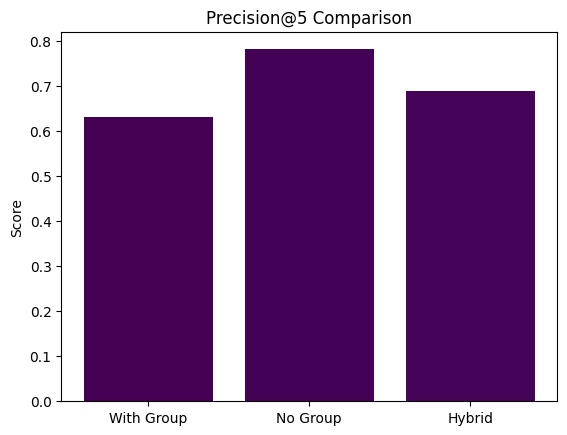

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df_results = pd.DataFrame([
    ["With Group", 0.630769, 0.182973, 0.761218],
    ["No Group", 0.780769, 0.265736, 0.846154],
    ["Hybrid", 0.688462, 0.206405, 0.823878],
], columns=["Model", "Precision@5", "Recall@5", "MRR"])


plt.figure()

plt.bar(
    df_results["Model"],
    df_results["Precision@5"],
    color=plt.cm.viridis(range(len(df_results)))
)

plt.title("Precision@5 Comparison")
plt.ylabel("Score")
plt.show()

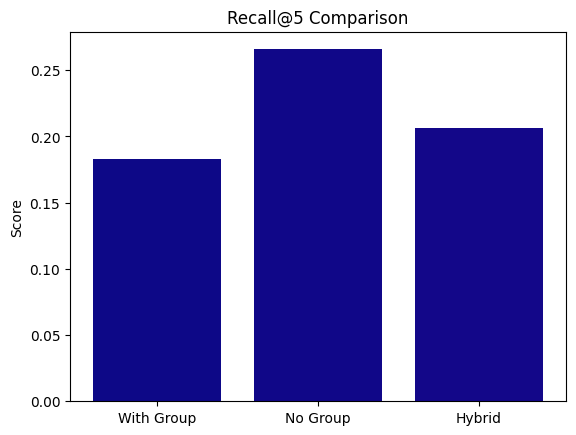

In [ ]:
plt.figure()

plt.bar(
    df_results["Model"],
    df_results["Recall@5"],
    color=plt.cm.plasma(range(len(df_results)))
)

plt.title("Recall@5 Comparison")
plt.ylabel("Score")
plt.show()

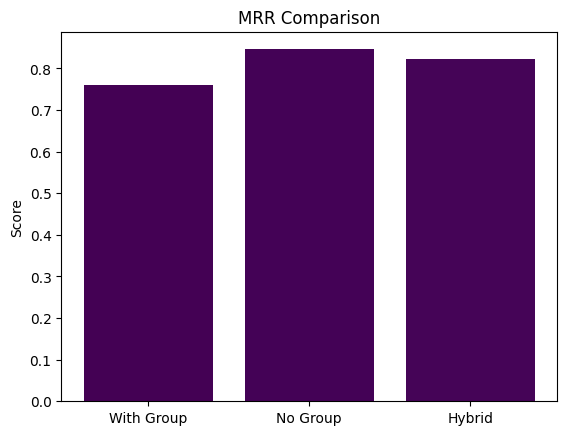

In [ ]:
plt.figure()

plt.bar(
    df_results["Model"],
    df_results["MRR"],
    color=plt.cm.viridis(range(len(df_results)))
)

plt.title("MRR Comparison")
plt.ylabel("Score")
plt.show()

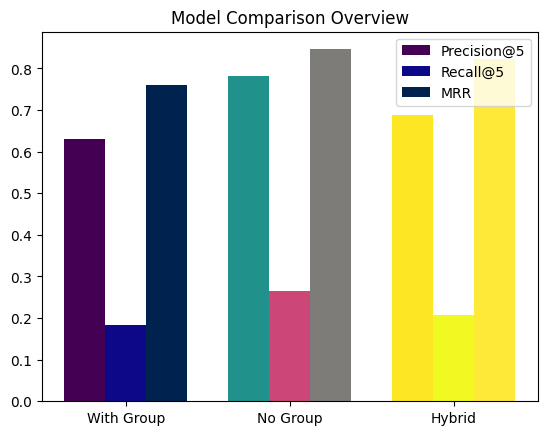

In [ ]:
import numpy as np

x = np.arange(len(df_results["Model"]))
width = 0.25

colors1 = plt.cm.viridis(np.linspace(0, 1, len(df_results)))
colors2 = plt.cm.plasma(np.linspace(0, 1, len(df_results)))
colors3 = plt.cm.cividis(np.linspace(0, 1, len(df_results)))

plt.figure()

plt.bar(x - width, df_results["Precision@5"], width, label="Precision@5", color=colors1)
plt.bar(x, df_results["Recall@5"], width, label="Recall@5", color=colors2)
plt.bar(x + width, df_results["MRR"], width, label="MRR", color=colors3)

plt.xticks(x, df_results["Model"])
plt.title("Model Comparison Overview")
plt.legend()
plt.show()

*italicized text*# **with improving ranking and evaltion and chunk**

with groub

In [ ]:
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer, util

# ============================================================
# CHUNKING FUNCTION
# ============================================================

def split_text_into_chunks(text, chunk_size=100):
    words = str(text).split()
    chunks = []

    for i in range(0, len(words), chunk_size):
        chunk = " ".join(words[i:i + chunk_size])
        if chunk.strip():
            chunks.append(chunk)

    return chunks

# ============================================================
# MODEL + EMBEDDINGS (MPNET)
# ============================================================

model = SentenceTransformer('all-mpnet-base-v2')

resume_chunks = []
resume_map = []

for idx, text in enumerate(df_all['cleanresume']):
    chunks = split_text_into_chunks(text, chunk_size=100)

    for chunk in chunks:
        resume_chunks.append(chunk)
        resume_map.append(idx)

# mapping CV -> chunks
cv_to_chunks = {}

for chunk_idx, cv_idx in enumerate(resume_map):
    if cv_idx not in cv_to_chunks:
        cv_to_chunks[cv_idx] = []
    cv_to_chunks[cv_idx].append(chunk_idx)

# Encode
resume_emb = model.encode(resume_chunks, convert_to_tensor=True)
job_emb = model.encode(df_job['clean_text'].tolist(), convert_to_tensor=True)

# Similarity
sim_matrix = util.cos_sim(resume_emb, job_emb).cpu().numpy()

# ============================================================
# HELPER
# ============================================================

def normalize_experience(exp):
    return min(exp / 5, 1)

# ============================================================
# MAIN FUNCTION (GROUP + CHUNK + IMPROVED RANKING)
# ============================================================

def get_top_cvs_with_group(job_idx, top_k=10):

    job_group = df_job.iloc[job_idx]['job_group']
    results = []

    threshold = np.percentile(sim_matrix[:, job_idx], 60)

    for i in range(len(df_all)):

        chunk_indices = cv_to_chunks.get(i, [])
        if not chunk_indices:
            continue

        # best chunk similarity
        sim = np.max(sim_matrix[chunk_indices, job_idx])

        if sim < threshold:
            continue

        exp = normalize_experience(df_all.loc[i, 'experience_years'])

        group_bonus = 0.15 if df_all.loc[i, 'job_group'] == job_group else 0

        # 🔥 improved ranking (keeps your logic but more stable)
        final_score = (
            0.70 * sim +
            0.20 * exp +
            group_bonus +
            0.10 * (sim * exp)
        )

        results.append({
            "resume_id": i,
            "score": float(final_score),
            "similarity": float(sim)
        })

    return sorted(results, key=lambda x: x["score"], reverse=True)[:top_k]

# ============================================================
# TEST
# ============================================================

for j in range(min(3, len(df_job))):

    print("\n----------------------------")
    print(f"\n================ JOB {j} ================")
    print("Job Group:", df_job.iloc[j]['job_group'])

    results = get_top_cvs_with_group(j)

    for rank, r in enumerate(results):

        print("\n----------------------------")
        print("Rank:", rank + 1)

        print("CV:\n", df_all.iloc[r["resume_id"]]["cleanresume"][:300])

        print("Score:", round(r["score"], 4))
        print("Similarity:", round(r["similarity"], 4))

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


without fillter

In [ ]:
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer, util

# ============================================================
# 0. CHUNKING FUNCTION
# ============================================================

def split_text_into_chunks(text, chunk_size=100):
    words = str(text).split()
    chunks = []

    for i in range(0, len(words), chunk_size):
        chunk = " ".join(words[i:i + chunk_size])
        if chunk.strip():
            chunks.append(chunk)

    return chunks

# ============================================================
# 1. MODEL + EMBEDDINGS (MPNET + CHUNK-BASED)
# ============================================================

model = SentenceTransformer('all-mpnet-base-v2')

resume_chunks = []
resume_map = []

for idx, text in enumerate(df_all['cleanresume']):
    chunks = split_text_into_chunks(text, chunk_size=100)

    for chunk in chunks:
        resume_chunks.append(chunk)
        resume_map.append(idx)

# FAST MAP
cv_to_chunks = {}
for chunk_idx, cv_idx in enumerate(resume_map):
    cv_to_chunks.setdefault(cv_idx, []).append(chunk_idx)

# Encode
resume_emb = model.encode(resume_chunks, convert_to_tensor=True)
job_emb = model.encode(df_job['clean_text'].tolist(), convert_to_tensor=True)

# Similarity
sim_matrix = util.cos_sim(resume_emb, job_emb).cpu().numpy()

# ============================================================
# 2. HELPERS
# ============================================================

def normalize_experience(exp, max_exp=5):
    if pd.isna(exp):
        return 0
    return min(exp / max_exp, 1)

# ============================================================
# 3. NO GROUP MODEL (WITH CHUNKING)
# ============================================================

def get_top_cvs_no_group(job_idx, top_k=10):

    results = []

    threshold = np.percentile(sim_matrix[:, job_idx], 60)

    for i in range(len(df_all)):

        chunk_indices = cv_to_chunks.get(i, [])
        if not chunk_indices:
            continue

        sim = np.max(sim_matrix[chunk_indices, job_idx])

        if sim < threshold:
            continue

        exp = normalize_experience(df_all.loc[i, 'experience_years'])

        final_score = (
            0.75 * sim +
            0.20 * exp +
            0.05 * (sim * exp)
        )

        results.append({
            "resume_id": i,
            "score": float(final_score),
            "similarity": float(sim)
        })

    return sorted(results, key=lambda x: x["score"], reverse=True)[:top_k]

# ============================================================
# 4. TEST OUTPUT
# ============================================================

for j in range(min(1, len(df_job))):

    print("\n==============================")
    print(f"JOB {j}")
    print("Job Group:", df_job.iloc[j]['job_group'])
    print("==============================\n")

    results = get_top_cvs_no_group(j)

    for rank, r in enumerate(results):

        print("----------------------------")
        print("Rank:", rank + 1)

        print("\nCV (preview):")
        print(df_all.iloc[r["resume_id"]]["cleanresume"][:300])

        print("\nScore:", round(r["score"], 4))
        print("Similarity:", round(r["similarity"], 4))

hyprid

In [ ]:
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer, util

# ============================================================
# 0. CHUNKING FUNCTION
# ============================================================

def split_text_into_chunks(text, chunk_size=100):
    words = str(text).split()
    chunks = []

    for i in range(0, len(words), chunk_size):
        chunk = " ".join(words[i:i + chunk_size])
        if chunk.strip():
            chunks.append(chunk)

    return chunks

# ============================================================
# 1. MODEL + EMBEDDINGS (MPNET + CHUNK-BASED)
# ============================================================

model = SentenceTransformer('all-mpnet-base-v2')

resume_chunks = []
resume_map = []

for idx, text in enumerate(df_all['cleanresume']):
    chunks = split_text_into_chunks(text, chunk_size=100)

    for chunk in chunks:
        resume_chunks.append(chunk)
        resume_map.append(idx)

# FAST MAP
cv_to_chunks = {}
for chunk_idx, cv_idx in enumerate(resume_map):
    cv_to_chunks.setdefault(cv_idx, []).append(chunk_idx)

# Encode
resume_emb = model.encode(resume_chunks, convert_to_tensor=True)
job_emb = model.encode(df_job['clean_text'].tolist(), convert_to_tensor=True)

# Similarity
sim_matrix = util.cos_sim(resume_emb, job_emb).cpu().numpy()

# ============================================================
# 2. HELPER FUNCTIONS
# ============================================================

def normalize_experience(exp, max_exp=5):
    if pd.isna(exp):
        return 0
    return min(exp / max_exp, 1)

# ============================================================
# 3. HYBRID MODEL (MPNET + CHUNKING)
# ============================================================

def get_top_cvs_hybrid(job_idx, top_k=10):

    job_group = df_job.iloc[job_idx]['job_group']
    results = []

    threshold = np.percentile(sim_matrix[:, job_idx], 60)

    for i in range(len(df_all)):

        chunk_indices = cv_to_chunks.get(i, [])
        if not chunk_indices:
            continue

        sim = np.max(sim_matrix[chunk_indices, job_idx])

        if sim < threshold:
            continue

        exp = normalize_experience(df_all.loc[i, 'experience_years'])

        group_bonus = 1 if df_all.loc[i, 'job_group'] == job_group else 0

        interaction = sim * exp

        final_score = (
            0.65 * sim +
            0.20 * exp +
            0.10 * group_bonus +
            0.05 * interaction
        )

        results.append({
            "resume_id": i,
            "score": float(final_score),
            "similarity": float(sim)
        })

    return sorted(results, key=lambda x: x["score"], reverse=True)[:top_k]

# ============================================================
# 4. TEST OUTPUT
# ============================================================

for j in range(min(1, len(df_job))):

    print("\n==============================")
    print(f"JOB {j}")
    print("Job Group:", df_job.iloc[j]['job_group'])
    print("==============================\n")

    results = get_top_cvs_hybrid(j)

    for rank, r in enumerate(results):

        print("----------------------------")
        print("Rank:", rank + 1)

        print("\nCV Preview:")
        print(df_all.iloc[r["resume_id"]]["cleanresume"][:300])

        print("\nScore:", round(r["score"], 4))
        print("Similarity:", round(r["similarity"], 4))

improved evaltion with less bieas


In [ ]:
def evaluate_system_weighted(pred_fn, K=5):

    precisions, recalls, mrrs, weights = [], [], [], []

    for j in range(len(df_job)):

        job_group = df_job.iloc[j]['job_group']
        weight = get_weight(job_group)

        results = pred_fn(j)
        pred = [r["resume_id"] for r in results]

        # ========================================================
        # Ground truth (chunk-based oracle approximation)
        # ========================================================
        scores = []

        for i in range(len(df_all)):
            chunk_indices = cv_to_chunks.get(i, [])

            if not chunk_indices:
                continue

            sim = np.max(sim_matrix[chunk_indices, j])
            scores.append((i, sim))

        true = [
            i for i, _ in sorted(scores, key=lambda x: x[1], reverse=True)[:K]
        ]

        precisions.append(precision_at_k(pred, true, K) * weight)
        recalls.append(recall_at_k(pred, true, K) * weight)
        mrrs.append(mrr(pred, true) * weight)

        weights.append(weight)

    return {
        "Precision@K": sum(precisions) / sum(weights),
        "Recall@K": sum(recalls) / sum(weights),
        "MRR": sum(mrrs) / sum(weights)
    }

In [1]:
print(df_results)

NameError: name 'df_results' is not defined